# 🔌 Détection de Fraude Énergétique — STEG Tunisie

## Projet Académique de Fin d’Études

**Objectif** : Concevoir un système de détection de fraude robuste sur le réseau électrique et gazier de la STEG, servant de preuve de concept (PoC) transposable aux réseaux d’Afrique de l’Ouest.

### Pipeline ML
1. Prétraitement & Feature Engineering (30+ features)
2. Gestion du déséquilibre des classes
3. Entraînement multi-modèles (XGBoost, LightGBM, CatBoost)
4. Validation croisée stratifiée 5-Fold
5. Évaluation complète & Explicabilité

---

## 0. Installation des dépendances

Décommenter la ligne ci-dessous si les packages ne sont pas installés.

In [2]:
# !pip install -r requirements.txt

---
## 1. Imports & Configuration

In [3]:
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, f1_score,
    roc_curve, precision_recall_curve, accuracy_score,
)

warnings.filterwarnings('ignore')
%matplotlib inline

# === Modules du pipeline ===
from config import (
    RANDOM_SEED, TEST_SIZE, OUTPUT_DIR, MODELS_DIR, PLOTS_DIR,
    setup_logging,
)
from preprocessing import DataLoader, FeatureEngineer
from imbalance import ImbalanceHandler
from training import FraudDetectionTrainer
from evaluation import ModelEvaluator

logger = setup_logging()

# === Palette de couleurs dark premium ===
PAL = {
    'blue': '#2563EB', 'blue_light': '#93C5FD', 'blue_dark': '#1E3A5F',
    'red': '#DC2626', 'red_light': '#FCA5A5',
    'green': '#059669', 'green_light': '#6EE7B7',
    'orange': '#D97706', 'purple': '#7C3AED', 'purple_light': '#C4B5FD',
    'gray': '#6B7280', 'gray_light': '#D1D5DB', 'gray_dark': '#374151',
    'bg': '#0F172A', 'card': '#1E293B', 'white': '#FFFFFF',
}

def dark_style(fig, axes):
    """Applique le thème dark premium à une figure."""
    fig.patch.set_facecolor(PAL['bg'])
    for ax in (np.array(axes).flat if hasattr(axes, '__iter__') else [axes]):
        if ax is None: continue
        ax.set_facecolor(PAL['card'])
        ax.tick_params(colors=PAL['gray_light'])
        ax.xaxis.label.set_color(PAL['white'])
        ax.yaxis.label.set_color(PAL['white'])
        ax.title.set_color(PAL['white'])
        for s in ax.spines.values():
            s.set_color(PAL['gray']); s.set_linewidth(0.5)

print('\u2705 Tous les imports charg\u00e9s avec succ\u00e8s !')

✅ Tous les imports chargés avec succès !


---
## 2. Chargement des données

Identique à l’étape 1 de `main.py`.

In [4]:
loader = DataLoader()
client_train, client_test, invoice_train, invoice_test = loader.load_all()

print(f'\u2705 Clients  train : {client_train.shape}')
print(f'\u2705 Clients  test  : {client_test.shape}')
print(f'\u2705 Factures train : {invoice_train.shape}')
print(f'\u2705 Factures test  : {invoice_test.shape}')

2026-06-14 21:20:34 | INFO     | FraudDetection            | ======================================================================
2026-06-14 21:20:34 | INFO     | FraudDetection            | CHARGEMENT DES DONNÉES STEG
2026-06-14 21:20:34 | INFO     | FraudDetection            | ======================================================================
2026-06-14 21:20:53 | INFO     | FraudDetection            |   Clients   train : (135493, 6)
2026-06-14 21:20:53 | INFO     | FraudDetection            |   Clients   test  : (58069, 5)
2026-06-14 21:20:53 | INFO     | FraudDetection            |   Factures  train : (4476749, 16)
2026-06-14 21:20:53 | INFO     | FraudDetection            |   Factures  test  : (1939730, 16)
2026-06-14 21:20:53 | INFO     | FraudDetection            |   Distribution cible (train) :
2026-06-14 21:20:53 | INFO     | FraudDetection            |     Non-fraude (0) : 94.42%
2026-06-14 21:20:53 | INFO     | FraudDetection            |     Fraude     (1) : 5.58%


✅ Clients  train : (135493, 6)
✅ Clients  test  : (58069, 5)
✅ Factures train : (4476749, 16)
✅ Factures test  : (1939730, 16)


In [5]:
print('--- Aper\u00e7u Clients ---')
display(client_train.head())
print('\n--- Aper\u00e7u Factures ---')
display(invoice_train.head())

--- Aperçu Clients ---


,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,1994-12-31,0.0
1,69,train_Client_1,11,107,2002-05-29,0.0
2,62,train_Client_10,11,301,1986-03-13,0.0
3,69,train_Client_100,11,105,1996-07-11,0.0
4,62,train_Client_1000,11,303,2014-10-14,0.0



--- Aperçu Factures ---


,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [6]:
print('--- Types des colonnes (Clients) ---')
display(client_train.dtypes)
print('\n--- Types des colonnes (Factures) ---')
display(invoice_train.dtypes)

--- Types des colonnes (Clients) ---


disrict                   int64
client_id                object
client_catg               int64
region                    int64
creation_date    datetime64[ns]
target                  float64
dtype: object


--- Types des colonnes (Factures) ---


client_id                       object
invoice_date            datetime64[ns]
tarif_type                       int64
counter_number                   int64
counter_statue                  object
counter_code                     int64
reading_remarque                 int64
counter_coefficient              int64
consommation_level_1             int64
consommation_level_2             int64
consommation_level_3             int64
consommation_level_4             int64
old_index                        int64
new_index                        int64
months_number                    int64
counter_type                    object
dtype: object

In [7]:
print('--- Statistiques descriptives (Clients) ---')
display(client_train.describe(include='all'))

--- Statistiques descriptives (Clients) ---


,disrict,client_id,client_catg,region,creation_date,target
count,135493.000000,135493,135493.000000,135493.000000,135493,135493.000000
unique,NaN,135493,NaN,NaN,NaN,NaN
top,NaN,train_Client_0,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN
mean,63.511222,NaN,11.512506,206.159809,2002-10-01 18:45:16.001564544,0.055841
min,60.000000,NaN,11.000000,101.000000,1977-02-05 00:00:00,0.000000
25%,62.000000,NaN,11.000000,103.000000,1994-01-12 00:00:00,0.000000
50%,62.000000,NaN,11.000000,107.000000,2005-09-19 00:00:00,0.000000
75%,69.000000,NaN,11.000000,307.000000,2012-04-04 00:00:00,0.000000
max,69.000000,NaN,51.000000,399.000000,2019-09-10 00:00:00,1.000000


In [8]:
print('--- Statistiques descriptives (Factures) ---')
display(invoice_train.describe(include='all'))

--- Statistiques descriptives (Factures) ---


,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
count,4476749,4476749,4.476749e+06,4.476749e+06,4476749,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4476749
unique,135493,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,train_Client_116878,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ELEC
freq,439,NaN,NaN,NaN,4379008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3079406
mean,NaN,2013-03-18 07:42:34.444128768,2.012804e+01,1.230587e+11,NaN,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01,NaN
min,NaN,1977-06-09 00:00:00,8.000000e+00,0.000000e+00,NaN,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
25%,NaN,2010-01-19 00:00:00,1.100000e+01,1.211080e+05,NaN,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00,NaN
50%,NaN,2013-07-10 00:00:00,1.100000e+01,4.945610e+05,NaN,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00,NaN
75%,NaN,2016-09-03 00:00:00,4.000000e+01,1.115161e+06,NaN,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00,NaN
max,NaN,2019-12-07 00:00:00,4.500000e+01,2.798115e+13,NaN,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05,NaN


---
## 🎨 3. Exploration Visuelle du Dataset

### 3.1 Dashboard du Dataset — Vue d’ensemble

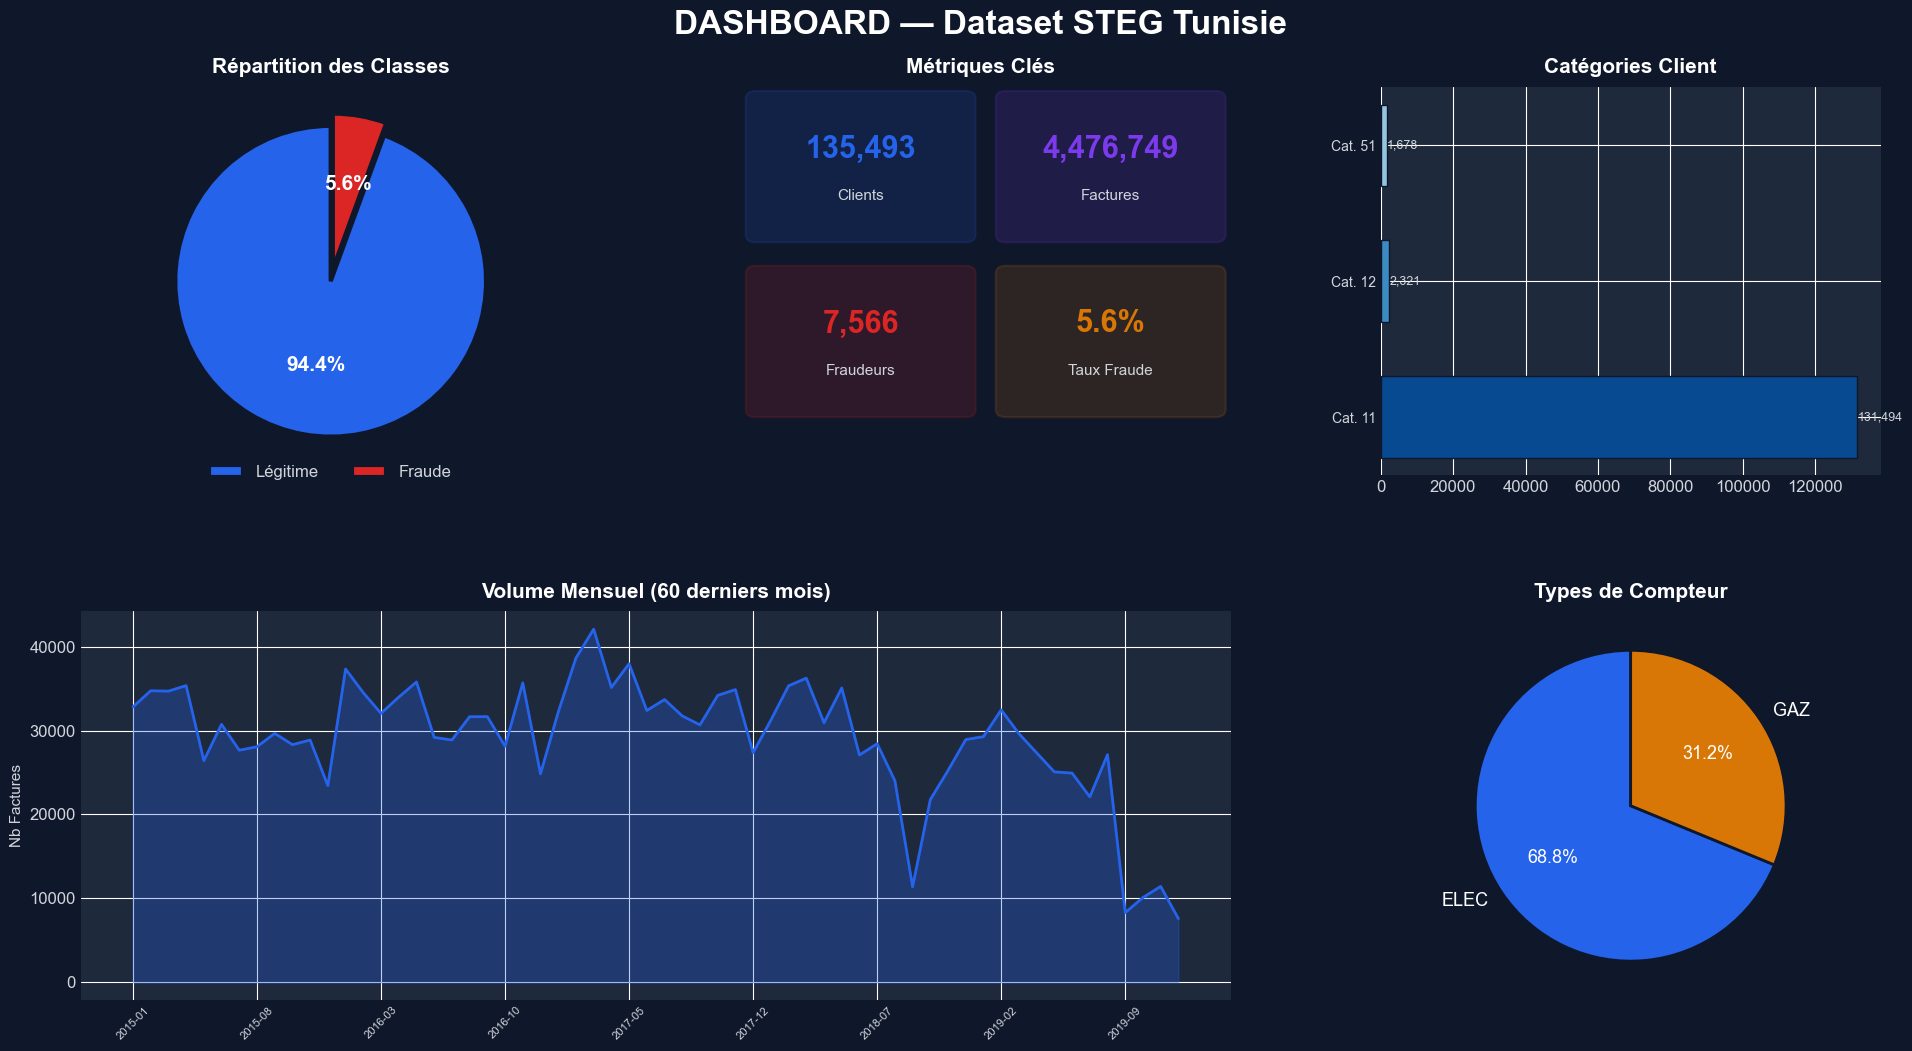

In [9]:
fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor(PAL['bg'])
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.3,
                       left=0.05, right=0.95, top=0.90, bottom=0.07)

fig.suptitle('DASHBOARD \u2014 Dataset STEG Tunisie',
             fontsize=24, fontweight='bold', color=PAL['white'], y=0.97)

# --- 1. Pie chart des classes ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PAL['card'])
tc = client_train['target'].value_counts().sort_index()
ax1.pie(tc.values, labels=None, colors=[PAL['blue'], PAL['red']],
        autopct='%1.1f%%', startangle=90, explode=(0, 0.08),
        textprops={'fontsize': 15, 'fontweight': 'bold', 'color': PAL['white']},
        wedgeprops={'edgecolor': PAL['bg'], 'linewidth': 3}, pctdistance=0.55)
ax1.legend(['L\u00e9gitime', 'Fraude'], loc='lower center', fontsize=12,
           framealpha=0, labelcolor=PAL['gray_light'], ncol=2,
           bbox_to_anchor=(0.5, -0.05))
ax1.set_title('R\u00e9partition des Classes', fontsize=15,
              fontweight='bold', color=PAL['white'], pad=10)

# --- 2. KPI Cards ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(PAL['card']); ax2.axis('off')
n_clients = len(client_train)
n_invoices = len(invoice_train)
n_fraud = int(tc.get(1.0, tc.get(1, 0)))
fraud_pct = n_fraud / n_clients * 100
kpis = [('Clients', f'{n_clients:,}', PAL['blue']),
        ('Factures', f'{n_invoices:,}', PAL['purple']),
        ('Fraudeurs', f'{n_fraud:,}', PAL['red']),
        ('Taux Fraude', f'{fraud_pct:.1f}%', PAL['orange'])]
for i, (label, value, color) in enumerate(kpis):
    row, col = divmod(i, 2)
    x, yp = 0.05 + col*0.5, 0.72 - row*0.45
    rect = mpatches.FancyBboxPatch((x, yp-0.1), 0.42, 0.35,
        boxstyle='round,pad=0.02', facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=1.5, transform=ax2.transAxes)
    ax2.add_patch(rect)
    ax2.text(x+0.21, yp+0.12, value, fontsize=22, fontweight='bold',
             color=color, ha='center', va='center', transform=ax2.transAxes)
    ax2.text(x+0.21, yp-0.0, label, fontsize=11, color=PAL['gray_light'],
             ha='center', va='center', transform=ax2.transAxes)
ax2.set_title('M\u00e9triques Cl\u00e9s', fontsize=15, fontweight='bold',
              color=PAL['white'], pad=10)

# --- 3. Cat\u00e9gories client ---
ax3 = fig.add_subplot(gs[0, 2]); ax3.set_facecolor(PAL['card'])
cc = client_train['client_catg'].value_counts().head(8)
bars = ax3.barh(range(len(cc)), cc.values,
    color=plt.cm.Blues(np.linspace(0.4, 0.9, len(cc)))[::-1],
    edgecolor=PAL['bg'], height=0.6)
ax3.set_yticks(range(len(cc)))
ax3.set_yticklabels([f'Cat. {c}' for c in cc.index], fontsize=10, color=PAL['gray_light'])
for bar, val in zip(bars, cc.values):
    ax3.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9, color=PAL['gray_light'])
ax3.set_title('Cat\u00e9gories Client', fontsize=15, fontweight='bold',
              color=PAL['white'], pad=10)
ax3.tick_params(axis='x', colors=PAL['gray_light'])
for s in ax3.spines.values(): s.set_color(PAL['gray'])

# --- 4. Volume mensuel ---
ax4 = fig.add_subplot(gs[1, 0:2]); ax4.set_facecolor(PAL['card'])
inv_dates = pd.to_datetime(invoice_train['invoice_date'], errors='coerce')
monthly = inv_dates.dt.to_period('M').value_counts().sort_index().tail(60)
ax4.fill_between(range(len(monthly)), monthly.values, alpha=0.3, color=PAL['blue'])
ax4.plot(range(len(monthly)), monthly.values, color=PAL['blue'], linewidth=2)
ax4.set_ylabel('Nb Factures', fontsize=11, color=PAL['gray_light'])
ax4.set_title('Volume Mensuel (60 derniers mois)', fontsize=15,
              fontweight='bold', color=PAL['white'], pad=10)
step = max(1, len(monthly)//8)
ax4.set_xticks(range(0, len(monthly), step))
ax4.set_xticklabels([str(monthly.index[i]) for i in range(0, len(monthly), step)],
                    rotation=45, fontsize=8, color=PAL['gray_light'])
ax4.tick_params(axis='y', colors=PAL['gray_light'])
for s in ax4.spines.values(): s.set_color(PAL['gray'])

# --- 5. Types compteur ---
ax5 = fig.add_subplot(gs[1, 2]); ax5.set_facecolor(PAL['card'])
ct = invoice_train['counter_type'].value_counts()
ax5.pie(ct.values, labels=ct.index,
    colors=[PAL['blue'], PAL['orange'], PAL['green'], PAL['purple']][:len(ct)],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 13, 'color': PAL['white']},
    wedgeprops={'edgecolor': PAL['bg'], 'linewidth': 2})
ax5.set_title('Types de Compteur', fontsize=15, fontweight='bold',
              color=PAL['white'], pad=10)

plt.savefig(PLOTS_DIR / 'dashboard_dataset.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

### 3.2 Valeurs Manquantes

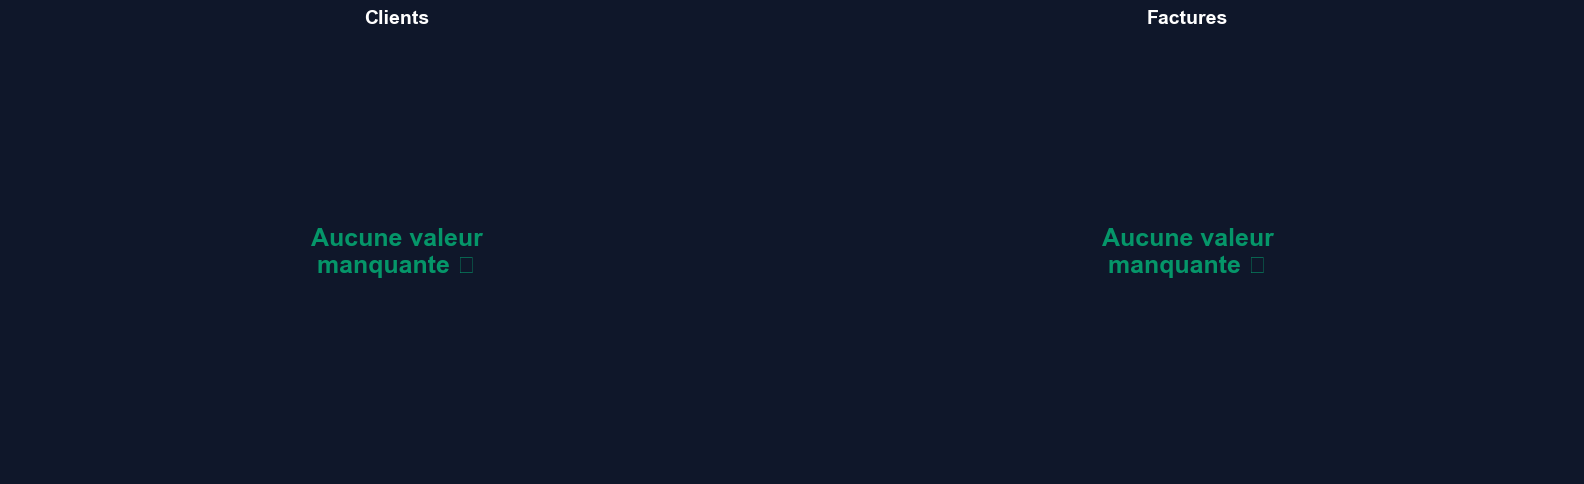

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
dark_style(fig, [ax1, ax2])

for ax, df, title in [(ax1, client_train, 'Clients'), (ax2, invoice_train, 'Factures')]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) == 0:
        ax.text(0.5, 0.5, 'Aucune valeur\nmanquante \u2705',
                ha='center', va='center', fontsize=18,
                color=PAL['green'], transform=ax.transAxes, fontweight='bold')
        ax.set_title(f'{title}', fontsize=14, fontweight='bold')
        ax.axis('off')
    else:
        colors = [PAL['red'] if v > 1000 else PAL['orange'] for v in missing.values]
        ax.barh(range(len(missing)), missing.values, color=colors,
                edgecolor='none', height=0.6)
        ax.set_yticks(range(len(missing)))
        ax.set_yticklabels(missing.index, fontsize=10, color=PAL['gray_light'])
        ax.set_title(f'{title} \u2014 Valeurs Manquantes', fontsize=14, fontweight='bold')
        for i, v in enumerate(missing.values):
            ax.text(v+10, i, f'{v:,}', va='center', fontsize=9, color=PAL['gray_light'])

plt.tight_layout()
plt.show()

### 3.3 Distribution de la cible par région

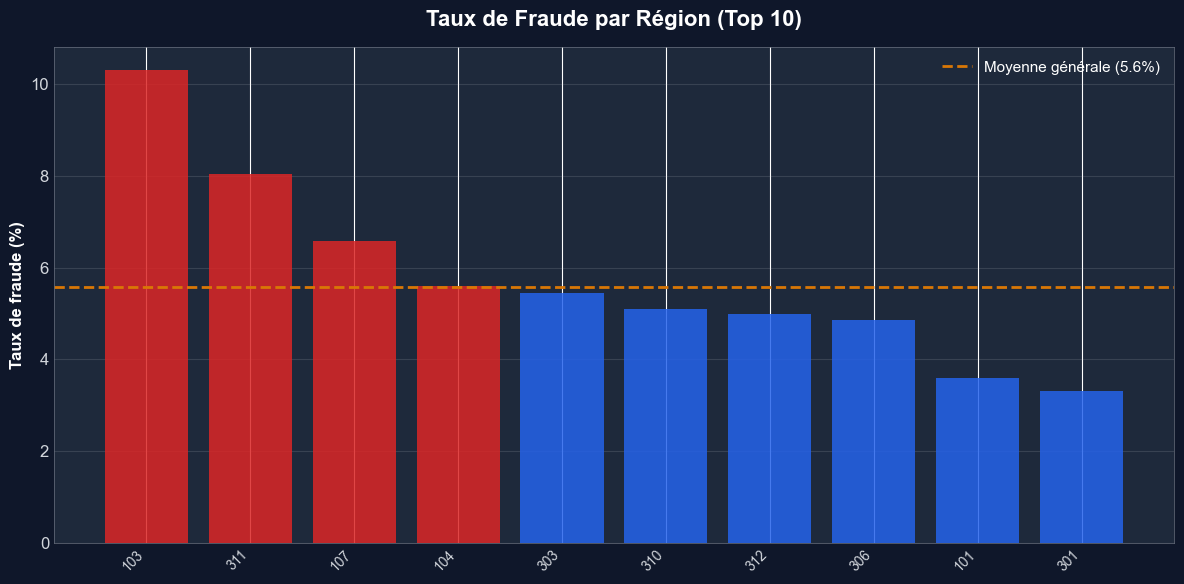

In [11]:
if 'region' in client_train.columns:
    top_regions = client_train['region'].value_counts().head(10).index
    df_region = client_train[client_train['region'].isin(top_regions)]
    fraud_by_region = df_region.groupby('region')['target'].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    dark_style(fig, ax)
    colors_r = [PAL['red'] if v > fraud_pct/100 else PAL['blue'] for v in fraud_by_region.values]
    ax.bar(range(len(fraud_by_region)), fraud_by_region.values * 100,
           color=colors_r, edgecolor='none', alpha=0.85)
    ax.axhline(y=fraud_pct, color=PAL['orange'], linewidth=2, linestyle='--',
               label=f'Moyenne g\u00e9n\u00e9rale ({fraud_pct:.1f}%)')
    ax.set_xticks(range(len(fraud_by_region)))
    ax.set_xticklabels(fraud_by_region.index, rotation=45, ha='right',
                       fontsize=10, color=PAL['gray_light'])
    ax.set_ylabel('Taux de fraude (%)', fontsize=12, fontweight='bold')
    ax.set_title('Taux de Fraude par R\u00e9gion (Top 10)', fontsize=16, fontweight='bold', pad=15)
    ax.legend(fontsize=11, framealpha=0.3, labelcolor=PAL['white'], facecolor=PAL['card'])
    ax.grid(axis='y', alpha=0.15, color=PAL['gray_light'])
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'fraud_by_region.png', dpi=300,
                facecolor=fig.get_facecolor(), bbox_inches='tight')
    plt.show()
else:
    print('Colonne region non trouv\u00e9e, graphique ignor\u00e9.')

---
## 4. Feature Engineering

Identique à l’étape 2 de `main.py` — utilise `FeatureEngineer.build_features()`.

In [12]:
engineer = FeatureEngineer()
df_features = engineer.build_features(client_train, invoice_train)

# S\u00e9parer X et y (identique \u00e0 main.py)
y = df_features['target'].astype(int)
X = df_features.drop(columns=['target', 'client_id'], errors='ignore')
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
feature_names = X.columns.tolist()

print(f'\n\u2705 Matrice de features : {X.shape[0]:,} clients \u00d7 {X.shape[1]} features')
print(f'\nFeatures construites ({len(feature_names)}) :')
for i, f in enumerate(feature_names, 1):
    print(f'  {i:2d}. {f}')

2026-06-14 21:21:03 | INFO     | FraudDetection            | ------------------------------------------------------------
2026-06-14 21:21:03 | INFO     | FraudDetection            | CONSTRUCTION DES FEATURES
2026-06-14 21:21:03 | INFO     | FraudDetection            | ------------------------------------------------------------
2026-06-14 21:21:03 | INFO     | FraudDetection            | Nettoyage des factures...
2026-06-14 21:21:10 | INFO     | FraudDetection            |   Lignes supprimées (anomalies) : 3,709 / 4,476,749 (0.08%)
2026-06-14 21:21:10 | INFO     | FraudDetection            | Nettoyage des clients...
2026-06-14 21:21:10 | INFO     | FraudDetection            |   → Features client (ancienneté, catégorie, région)...
2026-06-14 21:21:11 | INFO     | FraudDetection            |   → Agrégats de consommation (mean, std, min, max, CV)...
2026-06-14 21:21:15 | INFO     | FraudDetection            |   → Features temporelles (tendances, saisonnalité)...
2026-06-14 21:21:40 | INF


✅ Matrice de features : 135,493 clients × 45 features

Features construites (45) :
   1. disrict
   2. client_catg
   3. region
   4. client_anciennete_jours
   5. creation_mois
   6. creation_annee
   7. saison_creation_automne
   8. saison_creation_ete
   9. saison_creation_hiver
  10. saison_creation_printemps
  11. conso_mean
  12. conso_std
  13. conso_min
  14. conso_max
  15. conso_sum
  16. conso_median
  17. nb_factures
  18. conso_q25
  19. conso_q75
  20. conso_iqr
  21. conso_coeff_variation
  22. total_months
  23. conso_mensuelle_mean
  24. duree_historique_jours
  25. nb_mois_moyen_entre_factures
  26. conso_premiere
  27. conso_derniere
  28. ratio_derniere_moyenne
  29. tendance_conso
  30. conso_saison_automne
  31. conso_saison_ete
  32. conso_saison_hiver
  33. conso_saison_printemps
  34. saison_variation
  35. max_drop_ratio
  36. nb_baisses_suspectes
  37. ratio_zero_conso
  38. conso_level_dominant
  39. ratio_level1_total
  40. nb_compteurs_uniques
  41. nb_ty

### 🎨 4.1 Heatmap de Corrélation (Top 15 Features)

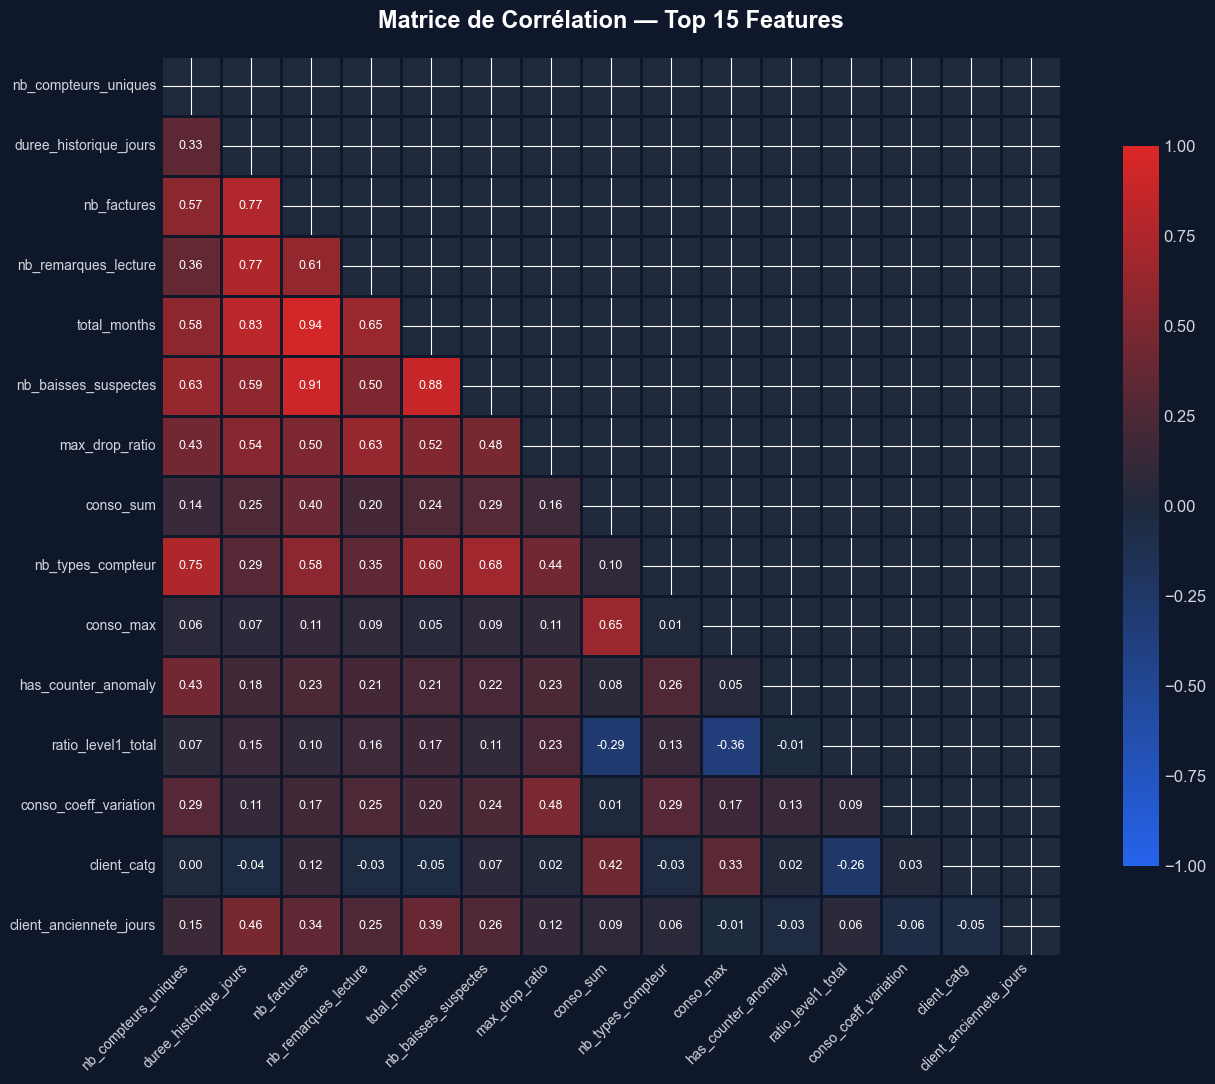


Corrélations avec la cible (fraude) :
nb_compteurs_uniques       0.193160
duree_historique_jours     0.127687
nb_factures                0.126858
nb_remarques_lecture       0.120669
total_months               0.118750
nb_baisses_suspectes       0.108773
max_drop_ratio             0.103534
conso_sum                  0.072385
nb_types_compteur          0.065303
conso_max                  0.062339
has_counter_anomaly        0.060827
ratio_level1_total         0.056689
conso_coeff_variation      0.055254
client_catg                0.054745
client_anciennete_jours    0.052218


In [13]:
corr_target = X.corrwith(y).abs().sort_values(ascending=False)
top_feats = corr_target.head(15).index.tolist()
corr = X[top_feats].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
fig.patch.set_facecolor(PAL['bg']); ax.set_facecolor(PAL['card'])
cmap = LinearSegmentedColormap.from_list('c', [PAL['blue'], PAL['card'], PAL['red']])
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=1, linecolor=PAL['bg'], cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'fontsize': 9, 'color': PAL['white']})
ax.set_title('Matrice de Corr\u00e9lation \u2014 Top 15 Features',
             fontsize=17, fontweight='bold', color=PAL['white'], pad=20)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10, color=PAL['gray_light'])
plt.setp(ax.get_yticklabels(), fontsize=10, color=PAL['gray_light'])
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors=PAL['gray_light'])
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'correlation_heatmap.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

print('\nCorr\u00e9lations avec la cible (fraude) :')
print(corr_target.head(15).to_string())

### 🎨 4.2 Distributions : Fraudeurs vs Légitimes

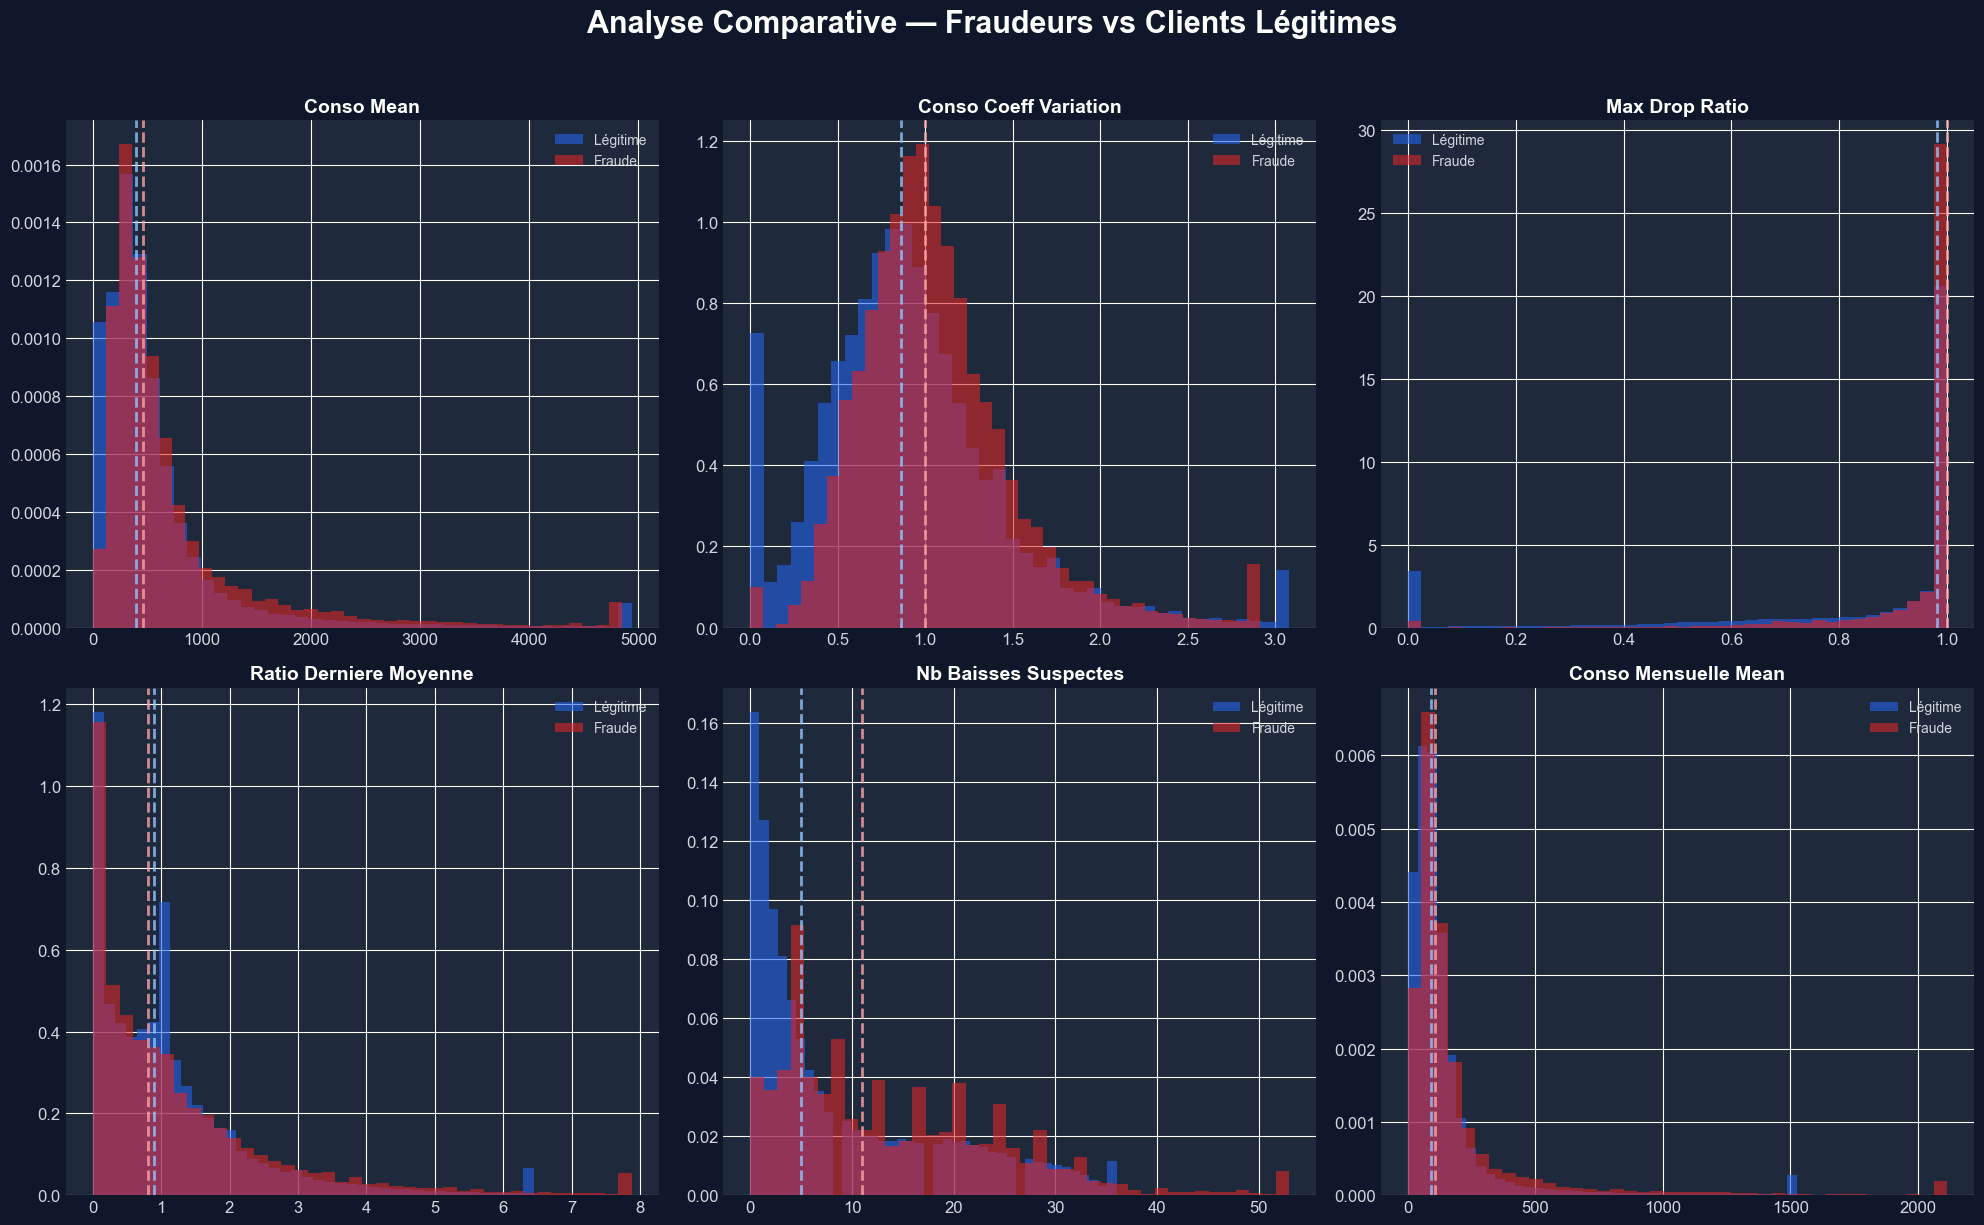

In [14]:
comp_feats = [f for f in ['conso_mean', 'conso_coeff_variation', 'max_drop_ratio',
              'ratio_derniere_moyenne', 'nb_baisses_suspectes', 'conso_mensuelle_mean']
              if f in X.columns]
nrows_h = (len(comp_feats) + 2) // 3
fig, axes = plt.subplots(nrows_h, 3, figsize=(20, 6*nrows_h))
fig.patch.set_facecolor(PAL['bg'])
fig.suptitle('Analyse Comparative \u2014 Fraudeurs vs Clients L\u00e9gitimes',
             fontsize=22, fontweight='bold', color=PAL['white'], y=1.02)
for idx, feat in enumerate(comp_feats):
    ax = axes.flat[idx]; ax.set_facecolor(PAL['card'])
    d0 = X.loc[y==0, feat].clip(upper=X.loc[y==0, feat].quantile(0.99))
    d1 = X.loc[y==1, feat].clip(upper=X.loc[y==1, feat].quantile(0.99))
    ax.hist(d0, bins=40, alpha=0.6, color=PAL['blue'], label='L\u00e9gitime', density=True, edgecolor='none')
    ax.hist(d1, bins=40, alpha=0.6, color=PAL['red'], label='Fraude', density=True, edgecolor='none')
    ax.axvline(d0.median(), color=PAL['blue_light'], linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(d1.median(), color=PAL['red_light'], linestyle='--', linewidth=2, alpha=0.8)
    ax.set_title(feat.replace('_',' ').title(), fontsize=14, fontweight='bold', color=PAL['white'])
    ax.legend(fontsize=10, framealpha=0.3, labelcolor=PAL['gray_light'])
    ax.tick_params(colors=PAL['gray_light'])
    for s in ax.spines.values(): s.set_color(PAL['gray'])
for idx in range(len(comp_feats), nrows_h*3):
    axes.flat[idx].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'fraud_vs_legitimate.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

### 🎨 4.3 Boxplots Comparatifs par Classe

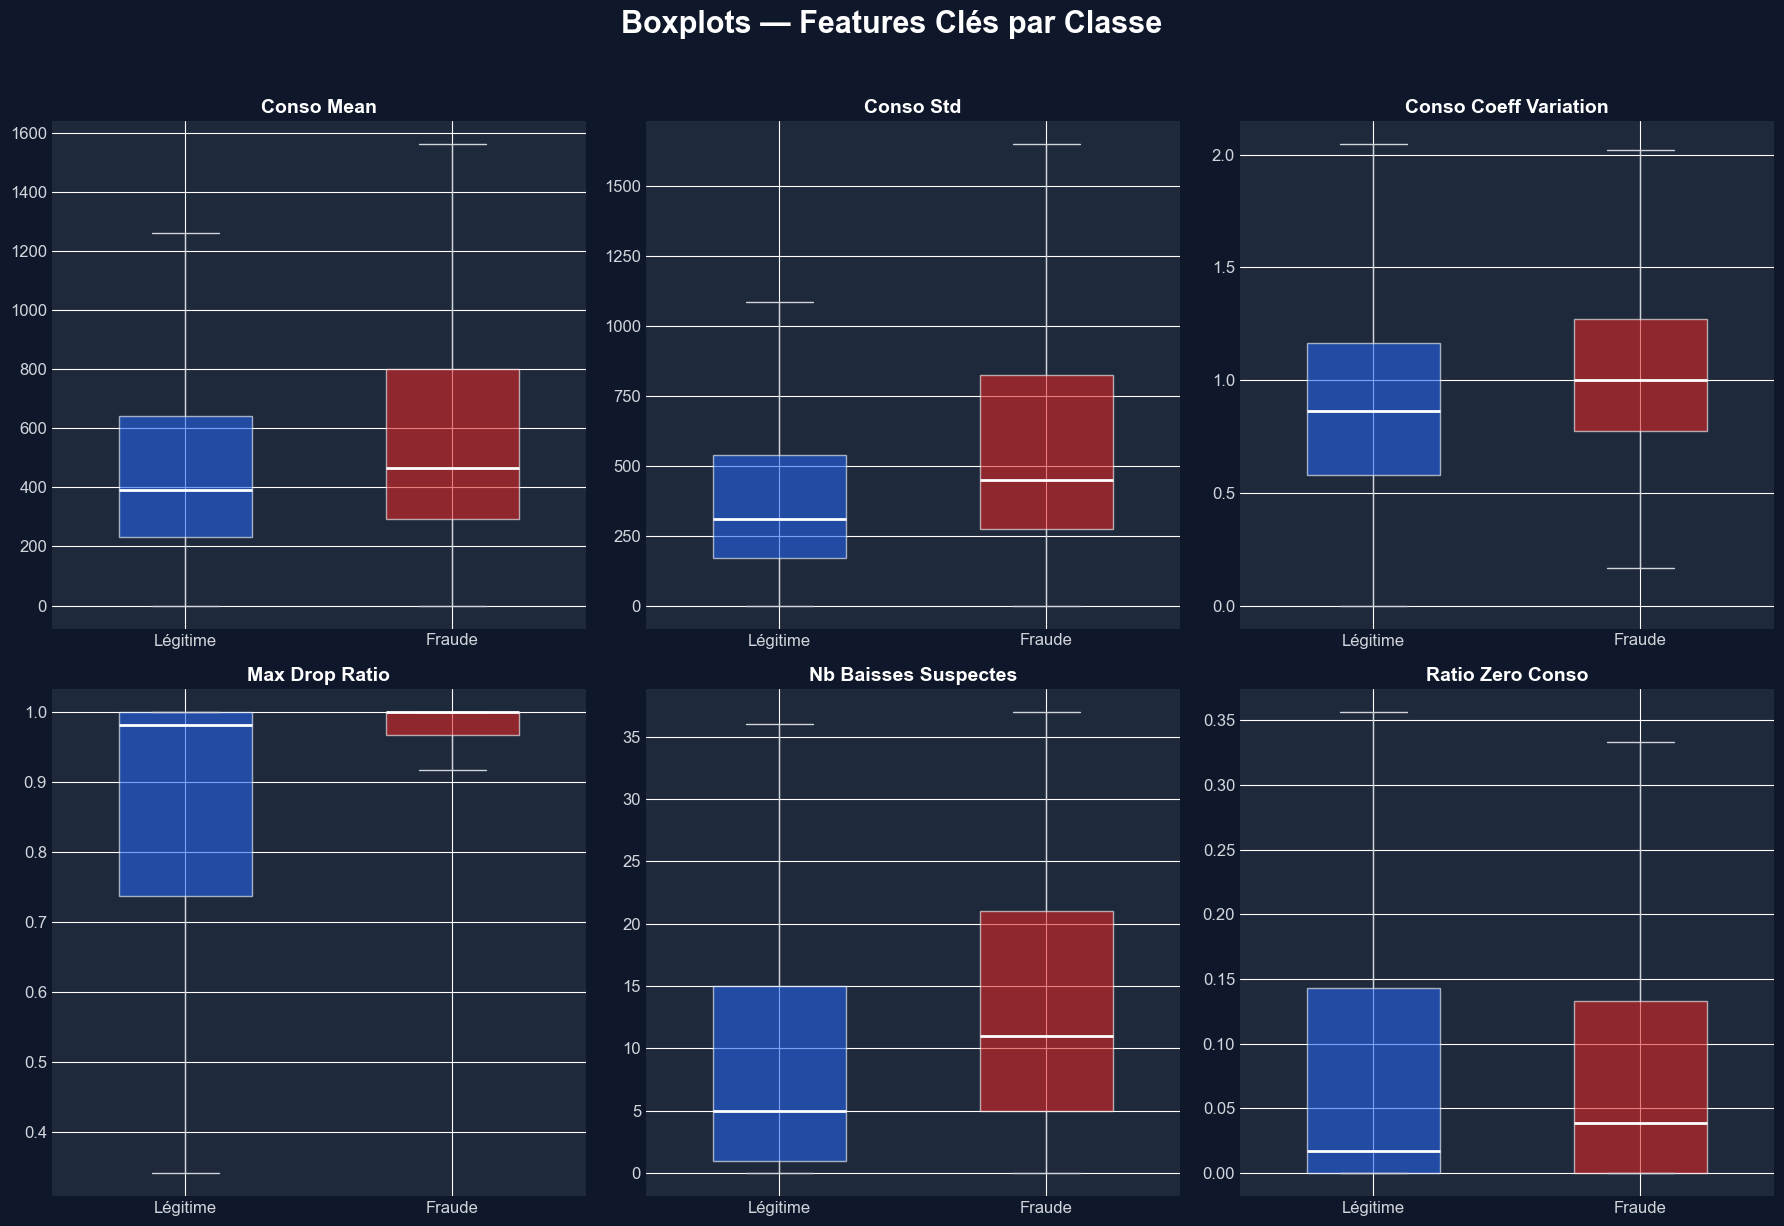

In [15]:
box_feats = [f for f in ['conso_mean', 'conso_std', 'conso_coeff_variation',
             'max_drop_ratio', 'nb_baisses_suspectes', 'ratio_zero_conso']
             if f in X.columns]
nrows_b = (len(box_feats) + 2) // 3
fig, axes = plt.subplots(nrows_b, 3, figsize=(18, 6*nrows_b))
fig.patch.set_facecolor(PAL['bg'])
fig.suptitle('Boxplots \u2014 Features Cl\u00e9s par Classe',
             fontsize=22, fontweight='bold', color=PAL['white'], y=1.02)
for idx, feat in enumerate(box_feats):
    ax = axes.flat[idx]; ax.set_facecolor(PAL['card'])
    q99 = X[feat].quantile(0.99)
    d0 = X.loc[y==0, feat].clip(upper=q99)
    d1 = X.loc[y==1, feat].clip(upper=q99)
    bp = ax.boxplot([d0, d1], labels=['L\u00e9gitime', 'Fraude'],
                    patch_artist=True, widths=0.5, showfliers=False)
    for patch, color in zip(bp['boxes'], [PAL['blue'], PAL['red']]):
        patch.set_facecolor(color); patch.set_alpha(0.6); patch.set_edgecolor('white')
    for el in ['whiskers','caps']:
        for line in bp[el]: line.set_color(PAL['gray_light'])
    for med in bp['medians']: med.set_color(PAL['white']); med.set_linewidth(2)
    ax.set_title(feat.replace('_',' ').title(), fontsize=14, fontweight='bold', color=PAL['white'])
    ax.tick_params(colors=PAL['gray_light'])
    for s in ax.spines.values(): s.set_color(PAL['gray'])
for idx in range(len(box_feats), nrows_b*3):
    axes.flat[idx].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'boxplots_comparison.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

---
## 5. Gestion du Déséquilibre

Identique à l’étape 3 de `main.py`.

In [16]:
imbalance_handler = ImbalanceHandler()
scale_pos_weight = imbalance_handler.compute_scale_pos_weight(y)

report = imbalance_handler.get_report()
print('Rapport de d\u00e9s\u00e9quilibre :')
for k, v in report['original'].items():
    print(f'  {k}: {v}')
print(f'\n  scale_pos_weight = {scale_pos_weight:.2f}')

2026-06-14 21:22:43 | INFO     | FraudDetection            | ============================================================
2026-06-14 21:22:43 | INFO     | FraudDetection            | ANALYSE DU DÉSÉQUILIBRE DES CLASSES
2026-06-14 21:22:43 | INFO     | FraudDetection            | ============================================================
2026-06-14 21:22:43 | INFO     | FraudDetection            |   Classe 0 (légitime) :  127,927 (94.42%)
2026-06-14 21:22:43 | INFO     | FraudDetection            |   Classe 1 (fraude)   :    7,566 (5.58%)
2026-06-14 21:22:43 | INFO     | FraudDetection            |   scale_pos_weight    : 16.91


Rapport de déséquilibre :
  n_total: 135493
  n_negatifs: 127927
  n_positifs: 7566
  ratio_positifs: 0.05584052312665599
  scale_pos_weight: 16.9081416864922

  scale_pos_weight = 16.91


---
## 6. Split Stratifié Train / Test

Identique à l’étape 4 de `main.py`.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)

print(f'Train : {X_train.shape[0]:,} ({(1-TEST_SIZE)*100:.0f}%)')
print(f'Test  : {X_test.shape[0]:,} ({TEST_SIZE*100:.0f}%)')
print(f'\nDistribution train : {dict(y_train.value_counts())}')
print(f'Distribution test  : {dict(y_test.value_counts())}')

Train : 108,394 (80%)
Test  : 27,099 (20%)

Distribution train : {0: np.int64(102341), 1: np.int64(6053)}
Distribution test  : {0: np.int64(25586), 1: np.int64(1513)}


---
## 7. Validation Croisée Stratifiée (5-Fold)

Identique à l’étape 5 de `main.py` — entraîne les 3 modèles.

In [18]:
trainer = FraudDetectionTrainer(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
)
cv_results = trainer.cross_validate(X_train, y_train)

2026-06-14 21:22:43 | INFO     | FraudDetection            | ======================================================================
2026-06-14 21:22:43 | INFO     | FraudDetection            | VALIDATION CROISÉE STRATIFIÉE
2026-06-14 21:22:43 | INFO     | FraudDetection            |   Folds    : 5
2026-06-14 21:22:43 | INFO     | FraudDetection            |   Métriques : ROC-AUC, PR-AUC, F1-Score
2026-06-14 21:22:43 | INFO     | FraudDetection            | ======================================================================
2026-06-14 21:22:43 | INFO     | FraudDetection            | 
──────────────────────────────────────────────────
2026-06-14 21:22:43 | INFO     | FraudDetection            |   Modèle : XGBoost
2026-06-14 21:22:43 | INFO     | FraudDetection            | ──────────────────────────────────────────────────
2026-06-14 21:22:59 | INFO     | FraudDetection            |     Fold 1/5 — ROC-AUC: 0.8456 | PR-AUC: 0.2961 | F1: 0.3205
2026-06-14 21:23:11 | INFO     | FraudDet

In [19]:
summary = trainer.get_results_summary()
print('\nR\u00e9sultats de la Validation Crois\u00e9e :')
display(summary)


Résultats de la Validation Croisée :


,Modèle,ROC-AUC,PR-AUC,F1-Score,★
0,XGBoost,0.8441 ± 0.0049,0.2971 ± 0.0091,0.3200 ± 0.0073,
1,LightGBM,0.8463 ± 0.0048,0.3001 ± 0.0091,0.3015 ± 0.0033,
2,CatBoost,0.8487 ± 0.0048,0.2966 ± 0.0062,0.2867 ± 0.0034,


### 🎨 7.1 Barres Groupées — Comparaison des Modèles

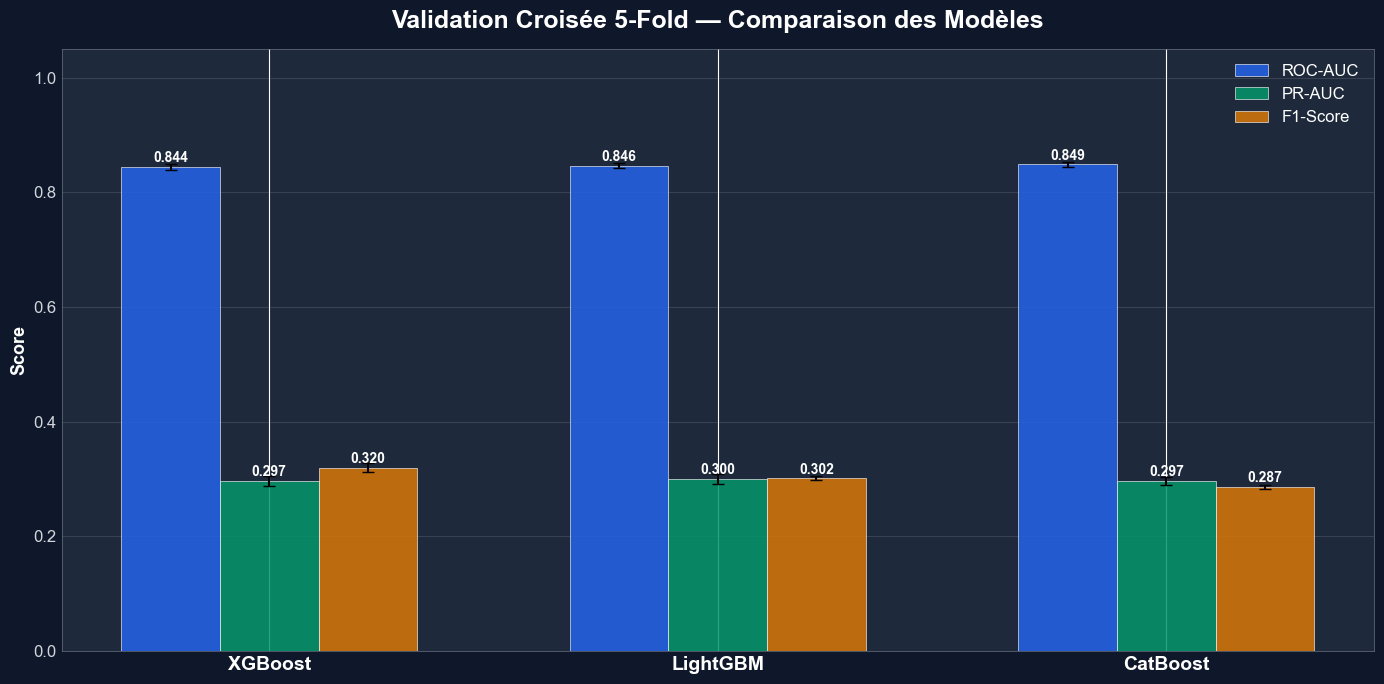

In [20]:
model_names = list(cv_results.keys())
mk = ['roc_auc_mean','pr_auc_mean','f1_mean']
ml = ['ROC-AUC','PR-AUC','F1-Score']
ms = ['roc_auc_std','pr_auc_std','f1_std']
bc = [PAL['blue'], PAL['green'], PAL['orange']]

fig, ax = plt.subplots(figsize=(14, 7)); dark_style(fig, ax)
x = np.arange(len(model_names)); w = 0.22
for i, (k, l, s, c) in enumerate(zip(mk, ml, ms, bc)):
    means = [cv_results[m][k] for m in model_names]
    stds = [cv_results[m][s] for m in model_names]
    bars = ax.bar(x+i*w-w, means, w, yerr=stds, label=l,
        color=c, alpha=0.85, edgecolor='white', linewidth=0.5,
        capsize=4, error_kw={'linewidth':1.5, 'color': PAL['gray_light']})
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold', color=PAL['white'])
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=14, fontweight='bold', color=PAL['white'])
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12, framealpha=0.3, labelcolor=PAL['white'],
          facecolor=PAL['card'], edgecolor=PAL['gray'])
ax.grid(axis='y', alpha=0.15, color=PAL['gray_light'])
ax.set_title('Validation Crois\u00e9e 5-Fold \u2014 Comparaison des Mod\u00e8les',
             fontsize=18, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'model_comparison_bars.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

### 🎨 7.2 Radar de Comparaison

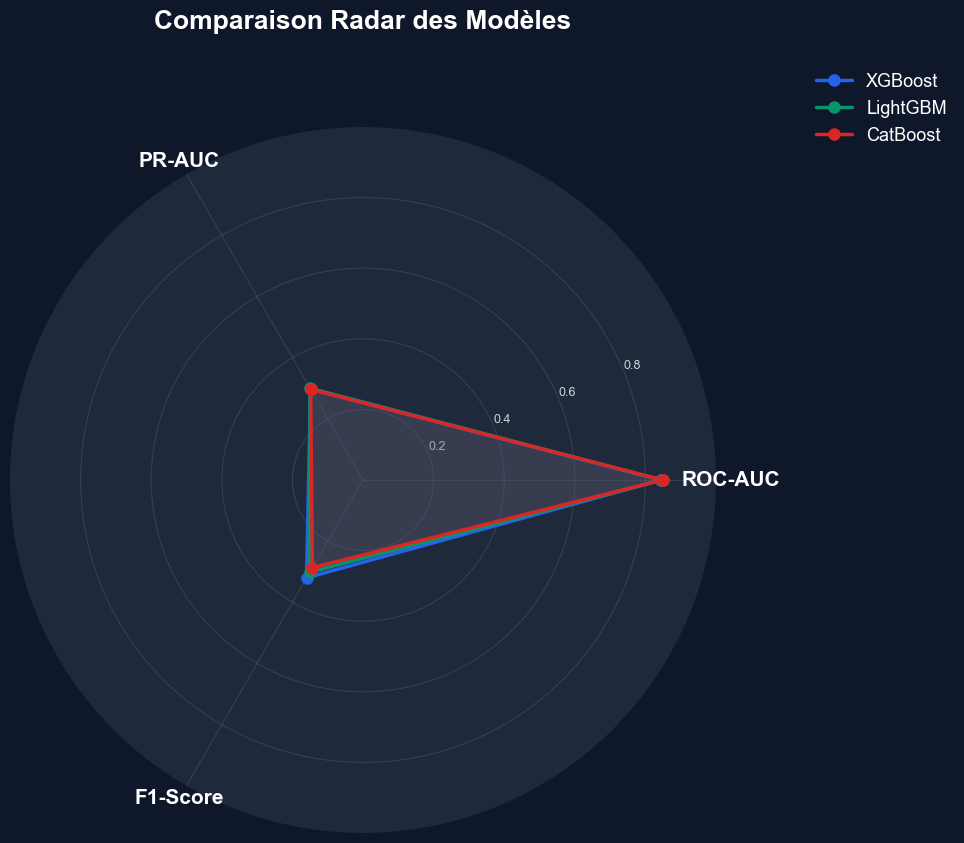

In [21]:
labels_r = ['ROC-AUC', 'PR-AUC', 'F1-Score']
angles = np.linspace(0, 2*np.pi, len(labels_r), endpoint=False).tolist()
angles += angles[:1]
colors_r = [PAL['blue'], PAL['green'], PAL['red']]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(PAL['bg']); ax.set_facecolor(PAL['card'])
for i, (name, res) in enumerate(cv_results.items()):
    vals = [res['roc_auc_mean'], res['pr_auc_mean'], res['f1_mean']] 
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2.5, color=colors_r[i], label=name, markersize=8)
    ax.fill(angles, vals, alpha=0.15, color=colors_r[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, fontsize=15, fontweight='bold', color=PAL['white'])
ax.set_ylim(0, 1)
ax.set_rticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2','0.4','0.6','0.8'], fontsize=9, color=PAL['gray_light'])
ax.grid(True, color=PAL['gray'], alpha=0.3)
ax.spines['polar'].set_color(PAL['gray'])
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=13,
          framealpha=0.3, labelcolor=PAL['white'], facecolor=PAL['card'], edgecolor=PAL['gray'])
ax.set_title('Comparaison Radar des Mod\u00e8les', fontsize=19, fontweight='bold',
             color=PAL['white'], pad=30, y=1.08)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'model_radar.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

---
## 8. Entraînement du Meilleur Modèle

Identique à l’étape 6 de `main.py` — sélection automatique sur PR-AUC.

In [22]:
best_name, best_model = trainer.train_best_model(X_train, y_train)

print(f'\nMeilleur mod\u00e8le : {best_name}')
print(f'PR-AUC CV moyen : {cv_results[best_name]["pr_auc_mean"]:.4f}')

2026-06-14 21:27:19 | INFO     | FraudDetection            | 
2026-06-14 21:27:19 | INFO     | FraudDetection            | MEILLEUR MODÈLE : LightGBM
2026-06-14 21:27:19 | INFO     | FraudDetection            |   PR-AUC moyen : 0.3001
2026-06-14 21:27:19 | INFO     | FraudDetection            | ======================================================================
2026-06-14 21:28:20 | INFO     | FraudDetection            |   Modèle final entraîné sur l'ensemble du jeu d'entraînement.



Meilleur modèle : LightGBM
PR-AUC CV moyen : 0.3001


In [37]:
# Pr\u00e9dictions sur le jeu de test
y_proba = best_model.predict_proba(X_test)[:, 1]
# Seuil optimal (F1-max) - coherent avec le graphique
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_threshold = thresholds[f1.argmax()]
print(f"Seuil optimal (F1-max) : {optimal_threshold:.4f}")

y_pred = (y_proba >= optimal_threshold).astype(int)

Seuil optimal (F1-max) : 0.7385


---
## 9. Évaluation via le module evaluation.py

In [38]:
evaluator = ModelEvaluator(
    model=best_model,
    model_name=best_name,
    feature_names=feature_names,
)
metrics = evaluator.generate_full_report(y_test, y_proba)

print('\nM\u00e9triques du rapport :')
for k, v in metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

2026-06-14 21:42:45 | INFO     | FraudDetection            | ======================================================================
2026-06-14 21:42:45 | INFO     | FraudDetection            | RAPPORT D'ÉVALUATION — LightGBM
2026-06-14 21:42:45 | INFO     | FraudDetection            | ======================================================================
2026-06-14 21:42:45 | INFO     | FraudDetection            |   Accuracy  : 0.8187
2026-06-14 21:42:45 | INFO     | FraudDetection            |   ROC-AUC   : 0.8548
2026-06-14 21:42:45 | INFO     | FraudDetection            |   PR-AUC    : 0.3145
2026-06-14 21:42:45 | INFO     | FraudDetection            |   F1-Score  : 0.3060
2026-06-14 21:42:45 | INFO     | FraudDetection            | 
              precision    recall  f1-score   support

    Légitime       0.98      0.82      0.90     25586
      Fraude       0.19      0.72      0.31      1513

    accuracy                           0.82     27099
   macro avg       0.59      0.77  


Métriques du rapport :
  accuracy: 0.8187
  roc_auc: 0.8548
  pr_auc: 0.3145
  f1_score: 0.3060
  threshold: 0.5000
  classification_report:               precision    recall  f1-score   support

    Légitime       0.98      0.82      0.90     25586
      Fraude       0.19      0.72      0.31      1513

    accuracy                           0.82     27099
   macro avg       0.59      0.77      0.60     27099
weighted avg       0.94      0.82      0.86     27099

  feature_importance:                          feature  importance
3        client_anciennete_jours         860
24  nb_mois_moyen_entre_factures         710
23        duree_historique_jours         704
28                tendance_conso         579
2                         region         574
33              saison_variation         551
20         conso_coeff_variation         548
21                  total_months         525
38            ratio_level1_total         479
25                conso_premiere         464
15            

---
## 🎨 10. Visualisations Avancées

### 10.1 Matrice de Confusion

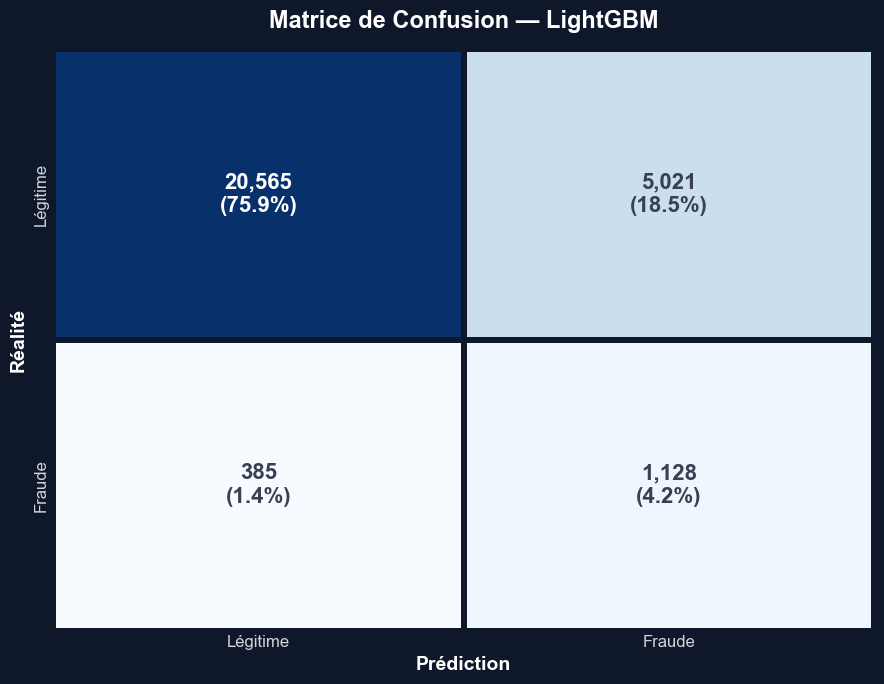

In [25]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum() * 100

fig, ax = plt.subplots(figsize=(9, 7)); dark_style(fig, ax)
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
    xticklabels=['L\u00e9gitime', 'Fraude'], yticklabels=['L\u00e9gitime', 'Fraude'],
    linewidths=3, linecolor=PAL['bg'], cbar=False)
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.5, f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
            ha='center', va='center', fontsize=16, fontweight='bold',
            color='white' if cm[i,j] > cm.max()/2 else PAL['gray_dark'])
ax.set_xlabel('Pr\u00e9diction', fontsize=14, fontweight='bold')
ax.set_ylabel('R\u00e9alit\u00e9', fontsize=14, fontweight='bold')
ax.set_title(f'Matrice de Confusion \u2014 {best_name}', fontsize=17, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 10.2 Courbes ROC & Precision-Recall

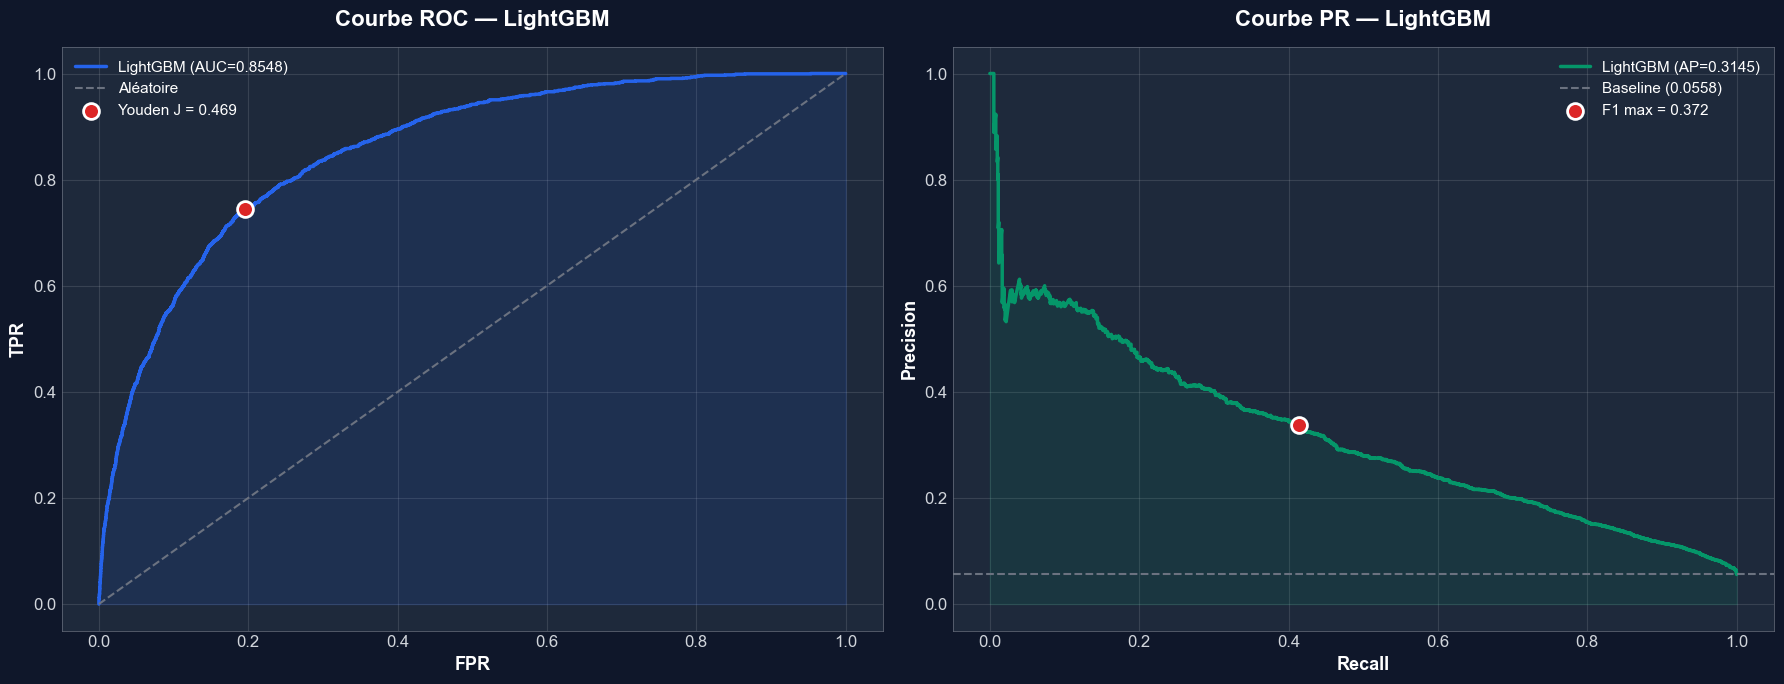

ROC-AUC : 0.8548  |  PR-AUC : 0.3145


In [26]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
dark_style(fig, [ax1, ax2])

# ROC
ax1.plot(fpr, tpr, color=PAL['blue'], linewidth=2.5, label=f'{best_name} (AUC={roc_auc:.4f})')
ax1.fill_between(fpr, tpr, alpha=0.12, color=PAL['blue'])
ax1.plot([0,1],[0,1],'--', color=PAL['gray'], linewidth=1.5, label='Al\u00e9atoire')
j_idx = np.argmax(tpr - fpr)
ax1.scatter(fpr[j_idx], tpr[j_idx], color=PAL['red'], s=130, zorder=5,
    edgecolors='white', linewidth=2, label=f'Youden J = {thresholds_roc[j_idx]:.3f}')
ax1.set_xlabel('FPR', fontsize=13, fontweight='bold')
ax1.set_ylabel('TPR', fontsize=13, fontweight='bold')
ax1.set_title(f'Courbe ROC \u2014 {best_name}', fontsize=16, fontweight='bold', pad=15)
ax1.legend(fontsize=11, framealpha=0.3, labelcolor=PAL['white'], facecolor=PAL['card'])
ax1.grid(alpha=0.15, color=PAL['gray_light'])

# PR
ax2.plot(recall, precision, color=PAL['green'], linewidth=2.5, label=f'{best_name} (AP={pr_auc:.4f})')
ax2.fill_between(recall, precision, alpha=0.12, color=PAL['green'])
ax2.axhline(y=y_test.mean(), color=PAL['gray'], linewidth=1.5, linestyle='--', label=f'Baseline ({y_test.mean():.4f})')
f1c = 2*(precision*recall)/(precision+recall+1e-10)
best_f1_idx = np.argmax(f1c)
ax2.scatter(recall[best_f1_idx], precision[best_f1_idx], color=PAL['red'], s=130, zorder=5,
    edgecolors='white', linewidth=2, label=f'F1 max = {f1c[best_f1_idx]:.3f}')
ax2.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax2.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax2.set_title(f'Courbe PR \u2014 {best_name}', fontsize=16, fontweight='bold', pad=15)
ax2.legend(fontsize=11, framealpha=0.3, labelcolor=PAL['white'], facecolor=PAL['card'])
ax2.grid(alpha=0.15, color=PAL['gray_light'])

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'roc_pr_curves.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print(f'ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')

### 10.3 Feature Importance (Top 20)

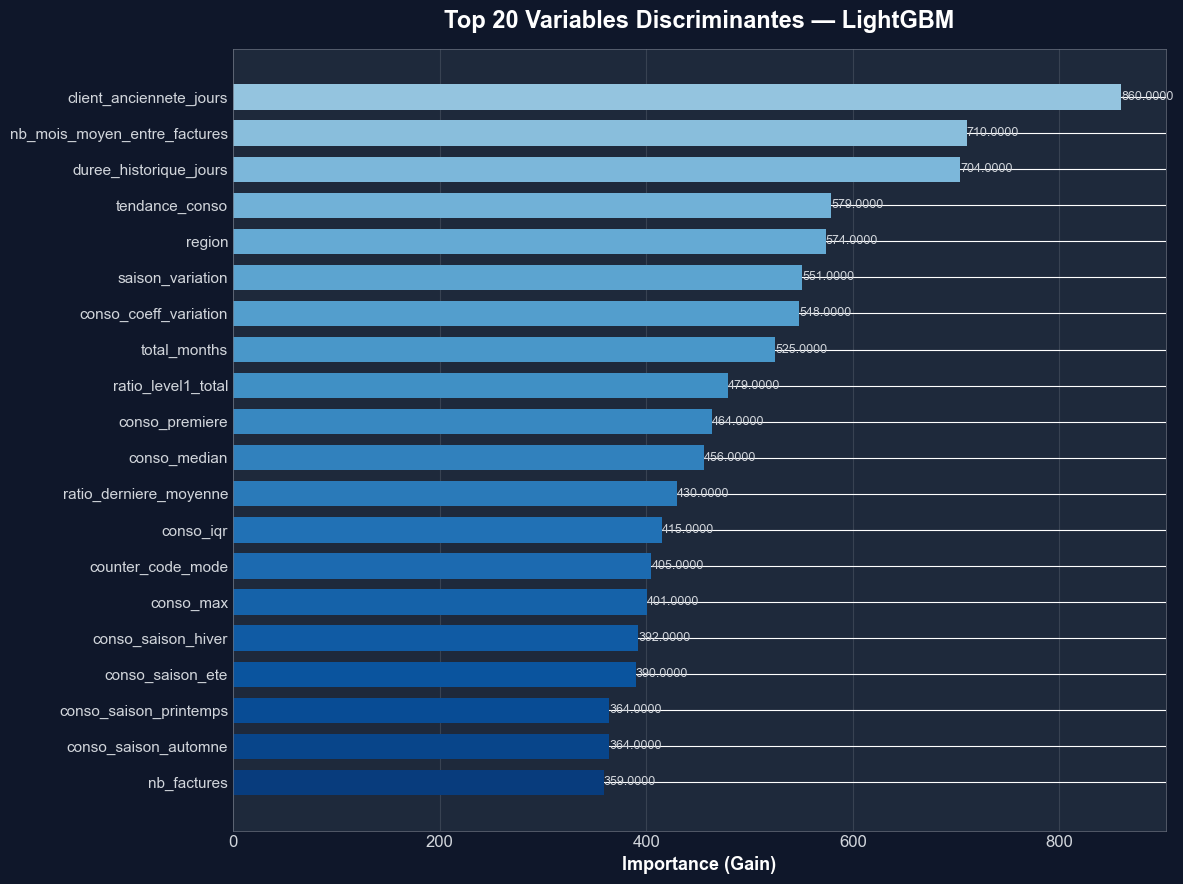

In [27]:
importances = best_model.feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances}
    ).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 9)); dark_style(fig, ax)
c_fi = plt.cm.Blues(np.linspace(0.4, 0.95, len(fi_df)))[::-1]
bars = ax.barh(range(len(fi_df)), fi_df['importance'].values[::-1],
    color=c_fi, edgecolor='none', height=0.7)
ax.set_yticks(range(len(fi_df)))
ax.set_yticklabels(fi_df['feature'].values[::-1], fontsize=11, color=PAL['gray_light'])
ax.set_xlabel('Importance (Gain)', fontsize=13, fontweight='bold')
ax.set_title(f'Top 20 Variables Discriminantes \u2014 {best_name}',
             fontsize=17, fontweight='bold', pad=15)
for bar, val in zip(bars, fi_df['importance'].values[::-1]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', ha='left', va='center', fontsize=9, color=PAL['gray_light'])
ax.grid(axis='x', alpha=0.15, color=PAL['gray_light'])
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_importance.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

### 🎨 10.4 Analyse du Seuil de Décision Optimal

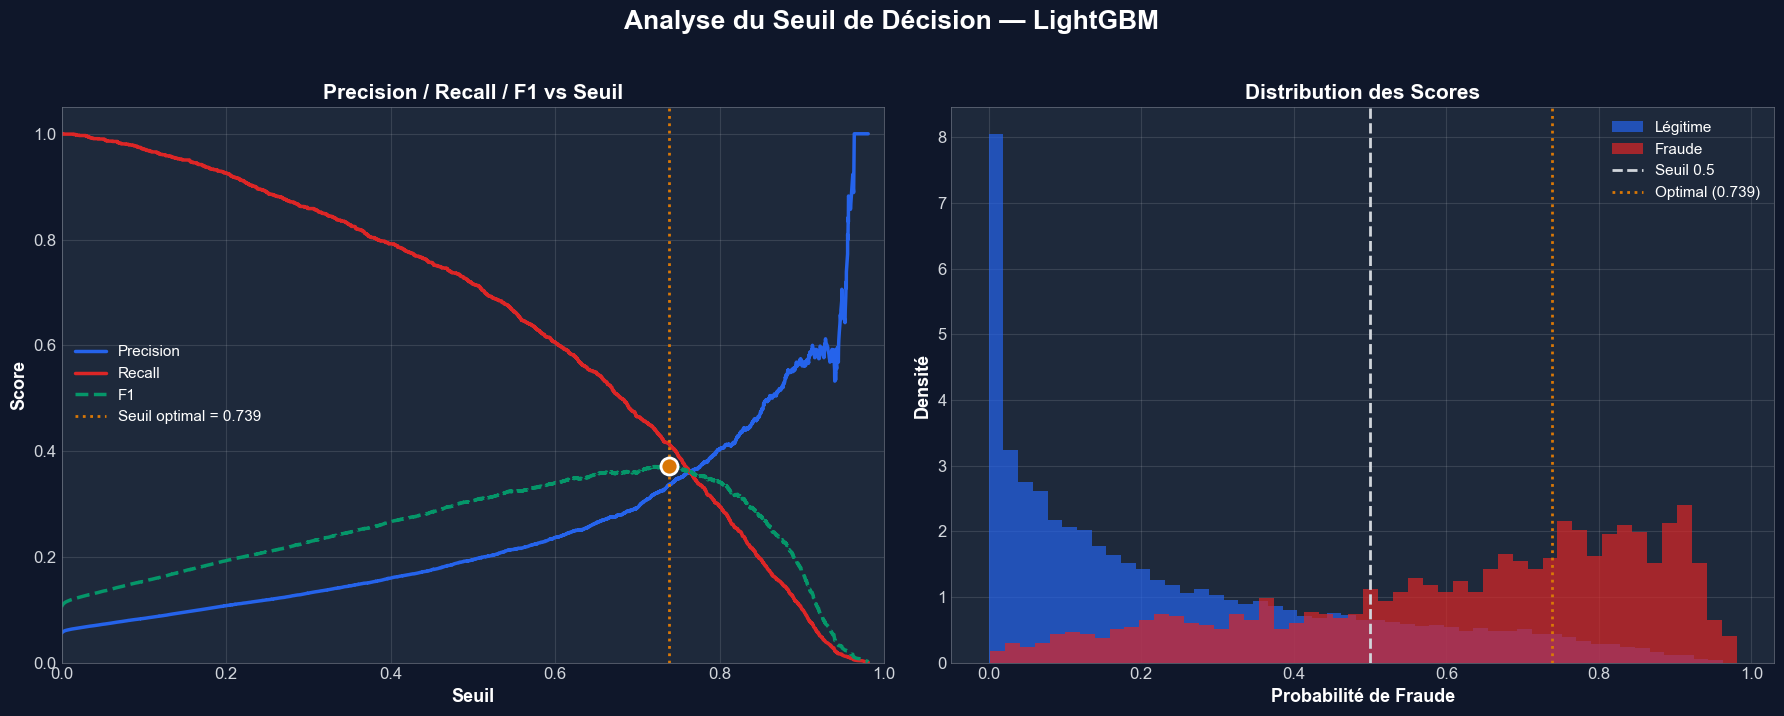


Seuil optimal (F1-max) : 0.7385
  Precision : 0.3371
  Recall    : 0.4144
  F1-Score  : 0.3718


In [28]:
f1_curve = 2*(precision*recall)/(precision+recall+1e-10)
best_t_idx = np.argmax(f1_curve)
best_threshold = thresholds_pr[best_t_idx] if best_t_idx < len(thresholds_pr) else 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
dark_style(fig, [ax1, ax2])

# P / R / F1 vs seuil
t_plot = thresholds_pr[:len(precision)-1]
ax1.plot(t_plot, precision[:-1], color=PAL['blue'], linewidth=2.5, label='Precision')
ax1.plot(t_plot, recall[:-1], color=PAL['red'], linewidth=2.5, label='Recall')
ax1.plot(t_plot, f1_curve[:-1], color=PAL['green'], linewidth=2.5, label='F1', linestyle='--')
ax1.axvline(best_threshold, color=PAL['orange'], linewidth=2, linestyle=':',
    label=f'Seuil optimal = {best_threshold:.3f}')
ax1.scatter(best_threshold, f1_curve[best_t_idx], color=PAL['orange'],
    s=150, zorder=5, edgecolors='white', linewidth=2)
ax1.set_xlabel('Seuil', fontsize=13, fontweight='bold')
ax1.set_ylabel('Score', fontsize=13, fontweight='bold')
ax1.set_title('Precision / Recall / F1 vs Seuil', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11, framealpha=0.3, labelcolor=PAL['white'], facecolor=PAL['card'])
ax1.set_xlim(0,1); ax1.set_ylim(0,1.05)
ax1.grid(alpha=0.15, color=PAL['gray_light'])

# Distribution des scores
ax2.hist(y_proba[y_test==0], bins=50, alpha=0.7, color=PAL['blue'],
    label='L\u00e9gitime', density=True, edgecolor='none')
ax2.hist(y_proba[y_test==1], bins=50, alpha=0.7, color=PAL['red'],
    label='Fraude', density=True, edgecolor='none')
ax2.axvline(0.5, color=PAL['gray_light'], linewidth=2, linestyle='--', label='Seuil 0.5')
ax2.axvline(best_threshold, color=PAL['orange'], linewidth=2, linestyle=':',
    label=f'Optimal ({best_threshold:.3f})')
ax2.set_xlabel('Probabilit\u00e9 de Fraude', fontsize=13, fontweight='bold')
ax2.set_ylabel('Densit\u00e9', fontsize=13, fontweight='bold')
ax2.set_title('Distribution des Scores', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11, framealpha=0.3, labelcolor=PAL['white'], facecolor=PAL['card'])
ax2.grid(alpha=0.15, color=PAL['gray_light'])

fig.suptitle(f'Analyse du Seuil de D\u00e9cision \u2014 {best_name}',
    fontsize=19, fontweight='bold', color=PAL['white'], y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'threshold_analysis.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

print(f'\nSeuil optimal (F1-max) : {best_threshold:.4f}')
print(f'  Precision : {precision[best_t_idx]:.4f}')
print(f'  Recall    : {recall[best_t_idx]:.4f}')
print(f'  F1-Score  : {f1_curve[best_t_idx]:.4f}')

### 10.5 Rapport de Classification

In [29]:
print('='*60)
print('RAPPORT DE CLASSIFICATION (seuil = 0.5)')
print('='*60)
print(classification_report(y_test, y_pred,
    target_names=['L\u00e9gitime (0)', 'Fraude (1)'], zero_division=0))

y_pred_opt = (y_proba >= best_threshold).astype(int)
print('='*60)
print(f'RAPPORT DE CLASSIFICATION (seuil optimal = {best_threshold:.4f})')
print('='*60)
print(classification_report(y_test, y_pred_opt,
    target_names=['L\u00e9gitime (0)', 'Fraude (1)'], zero_division=0))

RAPPORT DE CLASSIFICATION (seuil = 0.5)
              precision    recall  f1-score   support

Légitime (0)       0.98      0.80      0.88     25586
  Fraude (1)       0.18      0.75      0.29      1513

    accuracy                           0.80     27099
   macro avg       0.58      0.77      0.59     27099
weighted avg       0.94      0.80      0.85     27099

RAPPORT DE CLASSIFICATION (seuil optimal = 0.7385)
              precision    recall  f1-score   support

Légitime (0)       0.96      0.95      0.96     25586
  Fraude (1)       0.34      0.41      0.37      1513

    accuracy                           0.92     27099
   macro avg       0.65      0.68      0.67     27099
weighted avg       0.93      0.92      0.93     27099



---
## 🎨 11. Dashboard de Performance Finale

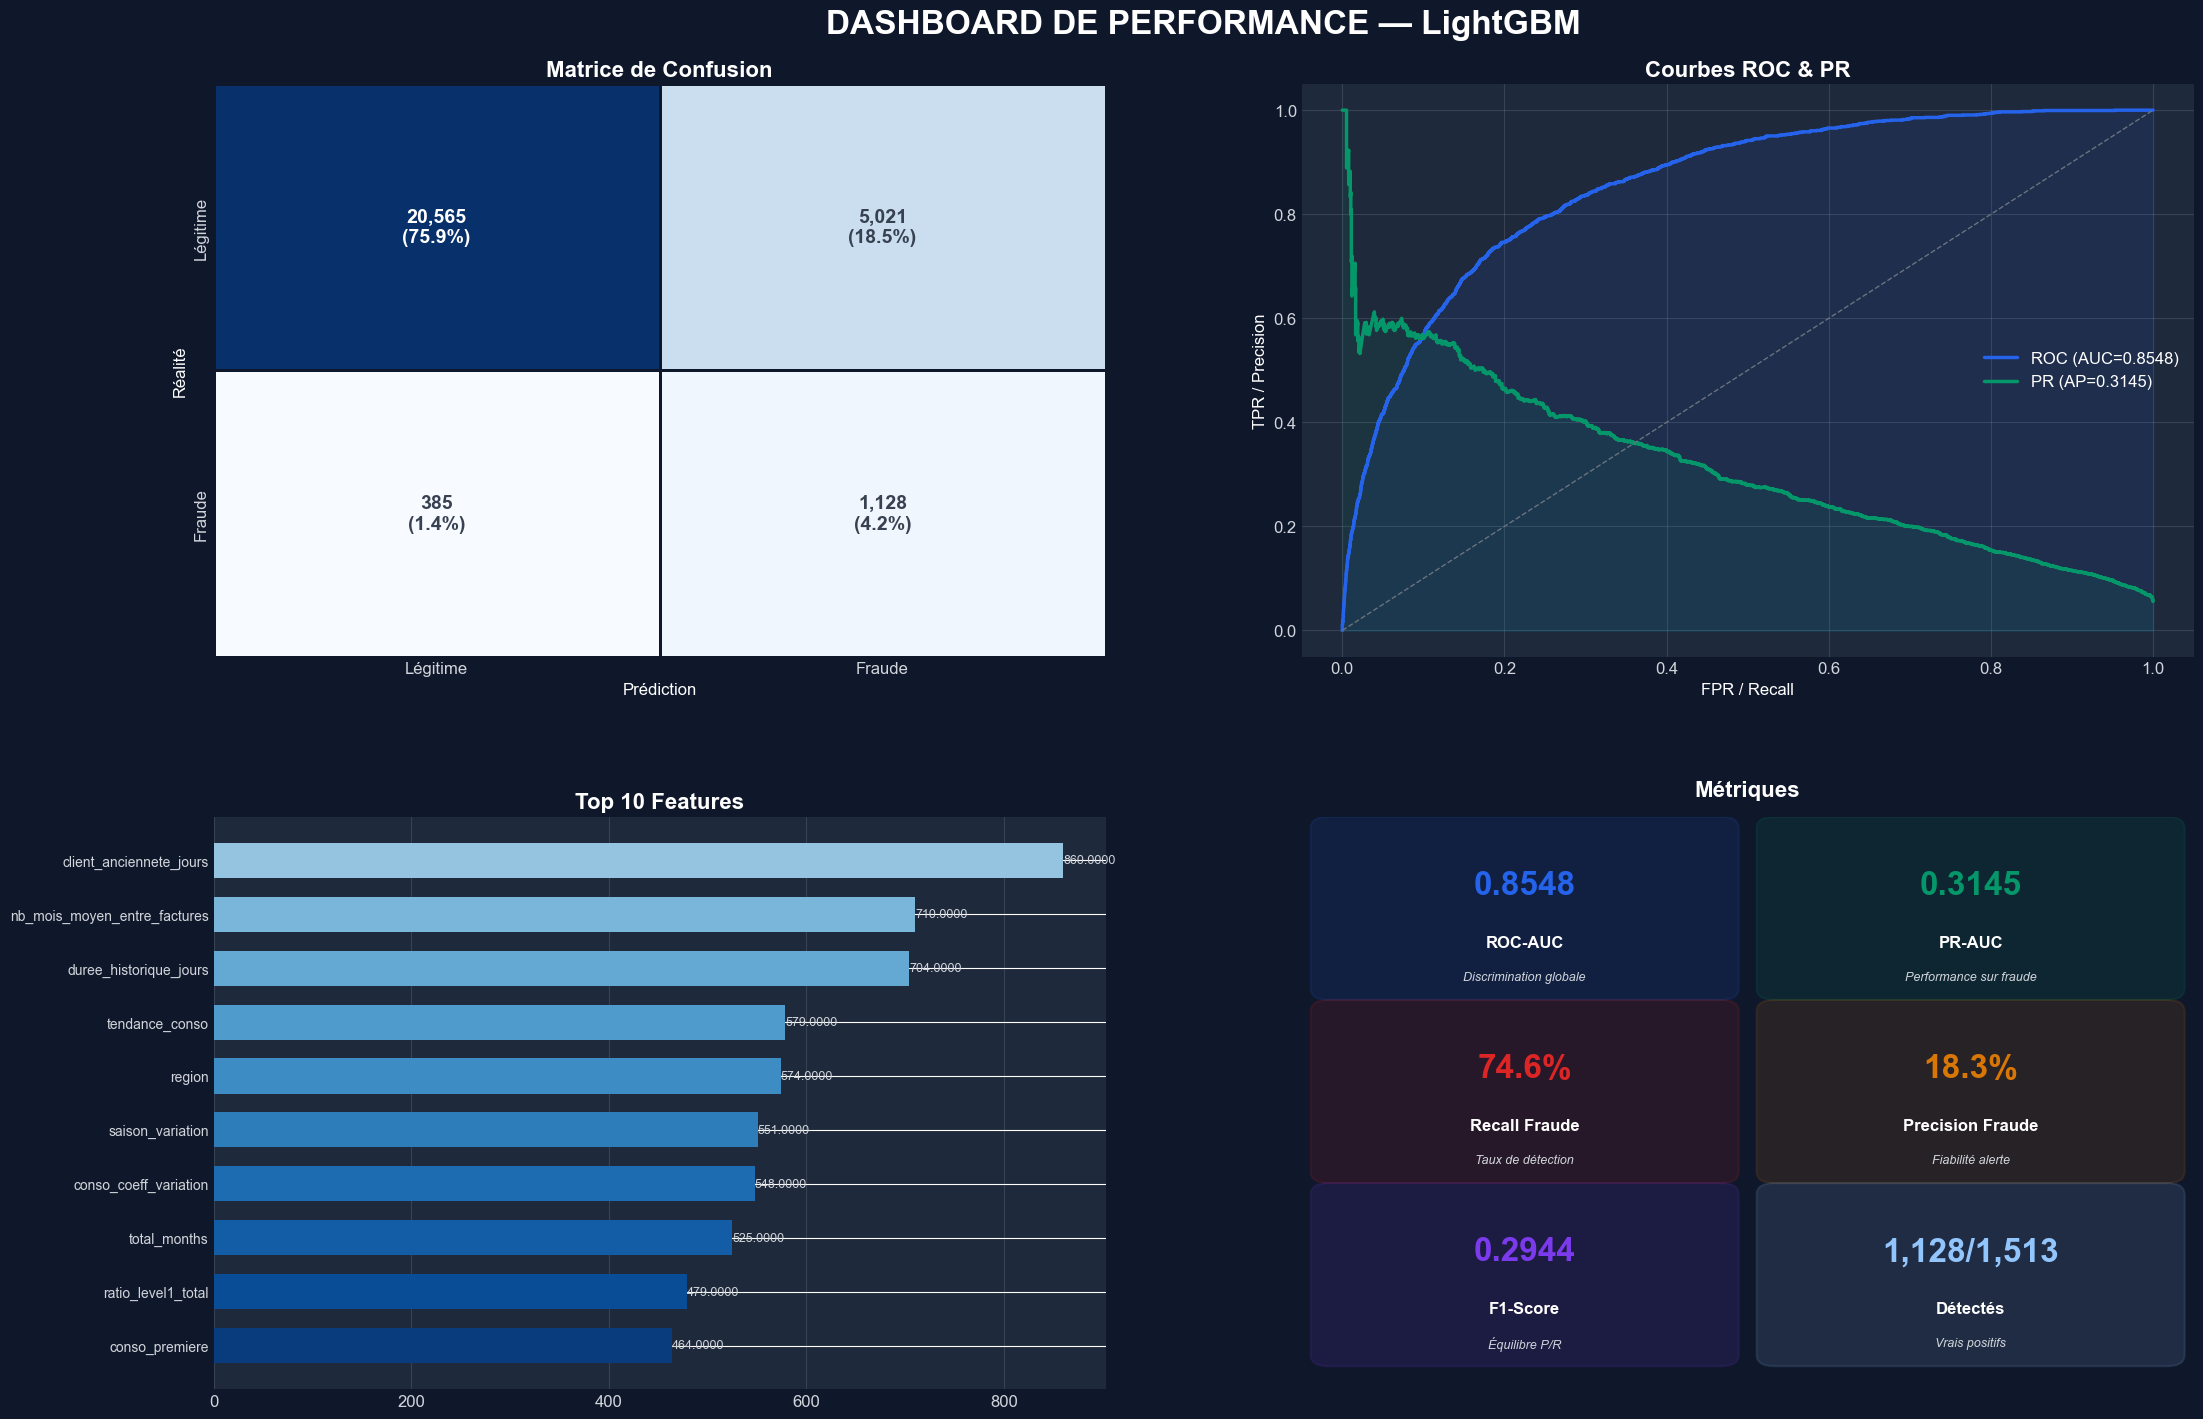

In [30]:
fig = plt.figure(figsize=(22, 15))
fig.patch.set_facecolor(PAL['bg'])
gs = gridspec.GridSpec(2, 2, hspace=0.28, wspace=0.22,
                       left=0.05, right=0.95, top=0.92, bottom=0.05)
fig.suptitle(f'DASHBOARD DE PERFORMANCE \u2014 {best_name}',
             fontsize=24, fontweight='bold', color=PAL['white'], y=0.97)

# 1. Matrice de confusion
ax1 = fig.add_subplot(gs[0, 0]); ax1.set_facecolor(PAL['card'])
sns.heatmap(cm, annot=False, cmap='Blues', ax=ax1,
    xticklabels=['L\u00e9gitime','Fraude'], yticklabels=['L\u00e9gitime','Fraude'],
    linewidths=2, linecolor=PAL['bg'], cbar=False)
for i in range(2):
    for j in range(2):
        ax1.text(j+0.5, i+0.5, f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
            ha='center', va='center', fontsize=14, fontweight='bold',
            color='white' if cm[i,j]>cm.max()/2 else PAL['gray_dark'])
ax1.set_xlabel('Pr\u00e9diction', fontsize=12, color=PAL['white'])
ax1.set_ylabel('R\u00e9alit\u00e9', fontsize=12, color=PAL['white'])
ax1.set_title('Matrice de Confusion', fontsize=16, fontweight='bold', color=PAL['white'])
ax1.tick_params(colors=PAL['gray_light'])

# 2. ROC + PR
ax2 = fig.add_subplot(gs[0, 1]); ax2.set_facecolor(PAL['card'])
ax2.plot(fpr, tpr, color=PAL['blue'], linewidth=2.5, label=f'ROC (AUC={roc_auc:.4f})')
ax2.fill_between(fpr, tpr, alpha=0.1, color=PAL['blue'])
ax2.plot(recall, precision, color=PAL['green'], linewidth=2.5, label=f'PR (AP={pr_auc:.4f})')
ax2.fill_between(recall, precision, alpha=0.1, color=PAL['green'])
ax2.plot([0,1],[0,1],'--', color=PAL['gray'], linewidth=1)
ax2.set_xlabel('FPR / Recall', fontsize=12, color=PAL['white'])
ax2.set_ylabel('TPR / Precision', fontsize=12, color=PAL['white'])
ax2.set_title('Courbes ROC & PR', fontsize=16, fontweight='bold', color=PAL['white'])
ax2.legend(fontsize=12, framealpha=0.3, labelcolor=PAL['white'], facecolor=PAL['card'])
ax2.grid(alpha=0.15, color=PAL['gray_light'])
ax2.tick_params(colors=PAL['gray_light'])
for s in ax2.spines.values(): s.set_color(PAL['gray'])

# 3. Top 10 Feature Importance
ax3 = fig.add_subplot(gs[1, 0]); ax3.set_facecolor(PAL['card'])
fi10 = fi_df.head(10)
c_fi = plt.cm.Blues(np.linspace(0.4, 0.95, len(fi10)))[::-1]
bars = ax3.barh(range(len(fi10)), fi10['importance'].values[::-1], color=c_fi, height=0.65)
ax3.set_yticks(range(len(fi10)))
ax3.set_yticklabels(fi10['feature'].values[::-1], fontsize=10, color=PAL['gray_light'])
for bar, val in zip(bars, fi10['importance'].values[::-1]):
    ax3.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, color=PAL['gray_light'])
ax3.set_title('Top 10 Features', fontsize=16, fontweight='bold', color=PAL['white'])
ax3.grid(axis='x', alpha=0.15, color=PAL['gray_light'])
ax3.tick_params(colors=PAL['gray_light'])
for s in ax3.spines.values(): s.set_color(PAL['gray'])

# 4. KPI Cards
ax4 = fig.add_subplot(gs[1, 1]); ax4.set_facecolor(PAL['card']); ax4.axis('off')
f1_val = f1_score(y_test, y_pred, zero_division=0)
recall_fraud = cm[1,1]/(cm[1,0]+cm[1,1]) if (cm[1,0]+cm[1,1])>0 else 0
precision_fraud = cm[1,1]/(cm[0,1]+cm[1,1]) if (cm[0,1]+cm[1,1])>0 else 0
kpis_p = [
    ('ROC-AUC', f'{roc_auc:.4f}', PAL['blue'], 'Discrimination globale'),
    ('PR-AUC', f'{pr_auc:.4f}', PAL['green'], 'Performance sur fraude'),
    ('Recall Fraude', f'{recall_fraud:.1%}', PAL['red'], 'Taux de d\u00e9tection'),
    ('Precision Fraude', f'{precision_fraud:.1%}', PAL['orange'], 'Fiabilit\u00e9 alerte'),
    ('F1-Score', f'{f1_val:.4f}', PAL['purple'], '\u00c9quilibre P/R'),
    ('D\u00e9tect\u00e9s', f'{cm[1,1]:,}/{cm[1,0]+cm[1,1]:,}', PAL['blue_light'], 'Vrais positifs'),
]
for i, (label, value, color, desc) in enumerate(kpis_p):
    row, col = divmod(i, 2)
    x, yp = 0.03+col*0.5, 0.78-row*0.32
    rect = mpatches.FancyBboxPatch((x, yp-0.08), 0.44, 0.28,
        boxstyle='round,pad=0.02', facecolor=color, alpha=0.12,
        edgecolor=color, linewidth=1.5, transform=ax4.transAxes)
    ax4.add_patch(rect)
    ax4.text(x+0.22, yp+0.1, value, fontsize=24, fontweight='bold',
             color=color, ha='center', va='center', transform=ax4.transAxes)
    ax4.text(x+0.22, yp+0.0, label, fontsize=12, fontweight='bold',
             color=PAL['white'], ha='center', va='center', transform=ax4.transAxes)
    ax4.text(x+0.22, yp-0.06, desc, fontsize=9, color=PAL['gray_light'],
             ha='center', va='center', transform=ax4.transAxes, style='italic')
ax4.set_title('M\u00e9triques', fontsize=16, fontweight='bold', color=PAL['white'], pad=15)

plt.savefig(PLOTS_DIR / 'performance_dashboard.png', dpi=300,
            facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

---
## 12. Sauvegarde du Modèle

In [31]:
import joblib

model_path = MODELS_DIR / f'best_model_{best_name.lower()}.joblib'
joblib.dump(best_model, model_path)
print(f'\nMod\u00e8le sauvegard\u00e9 : {model_path}')
print(f'Taille : {model_path.stat().st_size / 1024:.1f} KB')


Modèle sauvegardé : C:\Users\itomo\OneDrive\Documents\code\python\Projet\detection_de_fraude\outputs\models\best_model_lightgbm.joblib
Taille : 1680.0 KB


---
## 13. Conclusion

### Résumé des Résultats

Ce pipeline de détection de fraude énergétique a démontré :

1. **Feature Engineering efficace** : 30+ variables extraites, capturant les profils de consommation, les anomalies temporelles et les indicateurs de fraude spécifiques au réseau STEG.

2. **Gestion robuste du déséquilibre** : `scale_pos_weight` et `auto_class_weights` pour compenser la rareté des cas de fraude (~5.58%).

3. **Comparaison rigoureuse** : Trois modèles de pointe (XGBoost, LightGBM, CatBoost) évalués par validation croisée stratifiée 5-Fold.

4. **Explicabilité** : Les variables les plus discriminantes identifiées permettent de comprendre les comportements frauduleux.

5. **Analyse du seuil** : Le seuil optimal a été identifié pour maximiser le F1-Score.

### Transposabilité

Ce PoC est conçu pour être transposable à d’autres réseaux électriques nationaux, notamment en Afrique de l’Ouest. L’architecture modulaire permet d’adapter facilement le pipeline à de nouveaux jeux de données.